In [ ]:
import os
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU, MeanSquaredError
from tensorflow.keras.applications import VGG16
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_image_folder = '/content/drive/MyDrive/kvasir-seg/Kvasir-SEG/images'
base_mask_folder = '/content/drive/MyDrive/kvasir-seg/Kvasir-SEG/masks'

resized_image_folder = '/content/drive/MyDrive/kvasir-seg/Kvasir-SEG/resized_images'
resized_mask_folder = '/content/drive/MyDrive/kvasir-seg/Kvasir-SEG/resized_masks'

# Ensure output directories exist
os.makedirs(resized_image_folder, exist_ok=True)
os.makedirs(resized_mask_folder, exist_ok=True)

image_files = [f for f in os.listdir(base_image_folder) if f.endswith(('.png', '.jpg'))]
mask_files = [f for f in os.listdir(base_mask_folder) if f.endswith(('.png', '.jpg'))]

In [ ]:
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split

# Paths
base_morph_image_folder = '/content/drive/MyDrive/kvasir-seg/Kvasir-SEG/MO_Images'
resized_image_folder = '/content/drive/MyDrive/kvasir-seg/Kvasir-SEG/resized_images'
resized_mask_folder = '/content/drive/MyDrive/kvasir-seg/Kvasir-SEG/resized_masks'

# Morphological operations
morph_ops = ['original', 'eroded', 'dilated', 'opened', 'closed']
se = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# storage for each operation
X_data = {op: [] for op in morph_ops}
Y_data = {op: [] for op in morph_ops}

# Apply morphological operations to images and store
image_files = sorted(os.listdir(resized_image_folder))
mask_files = sorted(os.listdir(resized_mask_folder))

for op in morph_ops:
    for img_file, mask_file in zip(image_files, mask_files):
        img = cv2.imread(os.path.join(resized_image_folder, img_file))
        mask = cv2.imread(os.path.join(resized_mask_folder, mask_file), cv2.IMREAD_GRAYSCALE) / 255.0
        mask = np.expand_dims(mask, axis=-1)  # (H, W, 1)

        if op == 'original':
            img_processed = img
        else:
            img_processed = np.zeros_like(img)
            for c in range(img.shape[2]):  # Process each RGB channel separately
                if op == 'eroded':
                    img_processed[:, :, c] = cv2.erode(img[:, :, c], se)
                elif op == 'dilated':
                    img_processed[:, :, c] = cv2.dilate(img[:, :, c], se)
                elif op == 'opened':
                    img_processed[:, :, c] = cv2.morphologyEx(img[:, :, c], cv2.MORPH_OPEN, se)
                elif op == 'closed':
                    img_processed[:, :, c] = cv2.morphologyEx(img[:, :, c], cv2.MORPH_CLOSE, se)

        # Store images
        X_data[op].append(img_processed / 255.0)  # Normalize
        Y_data[op].append(mask)




In [ ]:
# Convert to numpy arrays
for op in morph_ops:
    X_data[op] = np.array(X_data[op], dtype=np.float32)
    Y_data[op] = np.array(Y_data[op], dtype=np.float32)

In [ ]:
import random
# Set a seed for reproducibility
random.seed(42)

In [ ]:

# Train-Test-Validation Split (for each operation)

split_data = {}

for op in morph_ops:
    X_train, X_temp, Y_train, Y_temp = train_test_split(X_data[op], Y_data[op], test_size=0.3, random_state=42)
    X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

    split_data[op] = {
        "train": (X_train, Y_train),
        "val": (X_val, Y_val),
        "test": (X_test, Y_test)
    }

    print(f"{op} -> Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

original -> Train: 700, Val: 150, Test: 150
eroded -> Train: 700, Val: 150, Test: 150
dilated -> Train: 700, Val: 150, Test: 150
opened -> Train: 700, Val: 150, Test: 150
closed -> Train: 700, Val: 150, Test: 150


In [ ]:
# Step 3: Select Specific Morphology to Train the Model
selected_op = 'original'  # Change this to 'eroded', 'dilated', ...
X_train, Y_train = split_data[selected_op]["train"]
X_val, Y_val = split_data[selected_op]["val"]
X_test, Y_test = split_data[selected_op]["test"]


Comined loss

In [ ]:
import tensorflow.keras.backend as K
from tensorflow.keras.losses import binary_crossentropy

# Dice Loss
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# IoU Loss
def iou_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

    return 1 - (intersection + smooth) / (union + smooth)

# Combined Loss Function
def combined_loss(y_true, y_pred, bce_weight=0, dice_weight=0.25, iou_weight=0.75):
    bce = binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    iou = iou_loss(y_true, y_pred)

    # Combining all three losses with specified weights
    return bce_weight * bce + dice_weight * dice + iou_weight * iou

In [ ]:
import numpy as np
import tensorflow.keras.backend as K

# Compute IoU (Intersection over Union)
def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Compute Dice Coefficient
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

**Models**

Simple UNET

In [ ]:
def unet_model(input_size=(64, 64, 3)):
    inputs = Input(input_size)
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)

    up1 = UpSampling2D(size=(2, 2))(conv3)
    merge1 = Concatenate()([conv2, up1])
    conv4 = Conv2D(128, (3, 3), activation='relu', padding='same')(merge1)

    up2 = UpSampling2D(size=(2, 2))(conv4)
    merge2 = Concatenate()([conv1, up2])
    conv5 = Conv2D(64, (3, 3), activation='relu', padding='same')(merge2)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv5)

    model = Model(inputs, outputs)
    return model

In [ ]:
model = unet_model()


In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

In [ ]:
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=300, batch_size=32)

Epoch 1/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.8503 - dice_coef: 0.7486 - iou_coef: 0.6045 - loss: 0.4224 - val_accuracy: 0.8067 - val_dice_coef: 0.6181 - val_iou_coef: 0.4482 - val_loss: 0.6058
Epoch 2/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8702 - dice_coef: 0.8180 - iou_coef: 0.6926 - loss: 0.3215 - val_accuracy: 0.8081 - val_dice_coef: 0.6200 - val_iou_coef: 0.4502 - val_loss: 0.6028
Epoch 3/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8723 - dice_coef: 0.8339 - iou_coef: 0.7158 - loss: 0.2961 - val_accuracy: 0.8196 - val_dice_coef: 0.6159 - val_iou_coef: 0.4461 - val_loss: 0.6096
Epoch 4/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8773 - dice_coef: 0.8394 - iou_coef: 0.7244 - loss: 0.2870 - val_accuracy: 0.8158 - val_dice_coef: 0.6228 - val_iou_coef: 0.4534 - val_loss: 0.6001
Epoch 5/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8752 - dice_coef: 0.8260 - iou_coef: 0.7043 - loss: 0.3088 - val_accuracy: 0.

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8271 - dice_coef: 0.6321 - iou_coef: 0.4628 - loss: 0.5867
Test Accuracy: 0.8250227570533752
Test Dice Coefficient: 0.5958450436592102
Test IoU: 0.46333521604537964


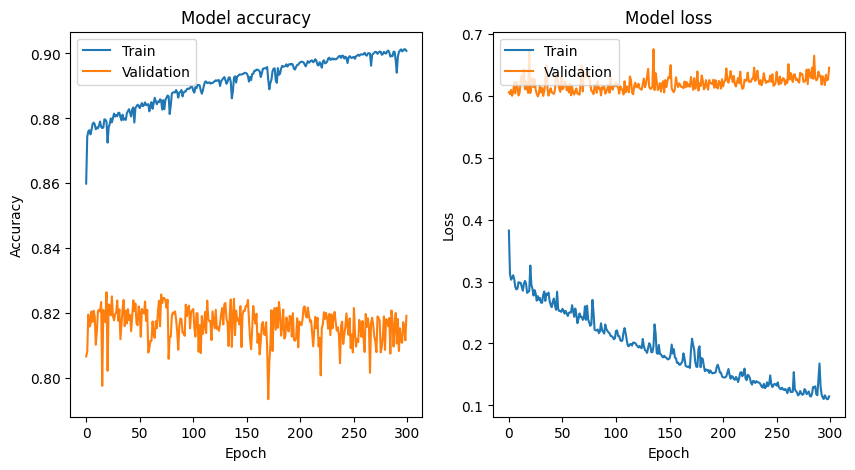

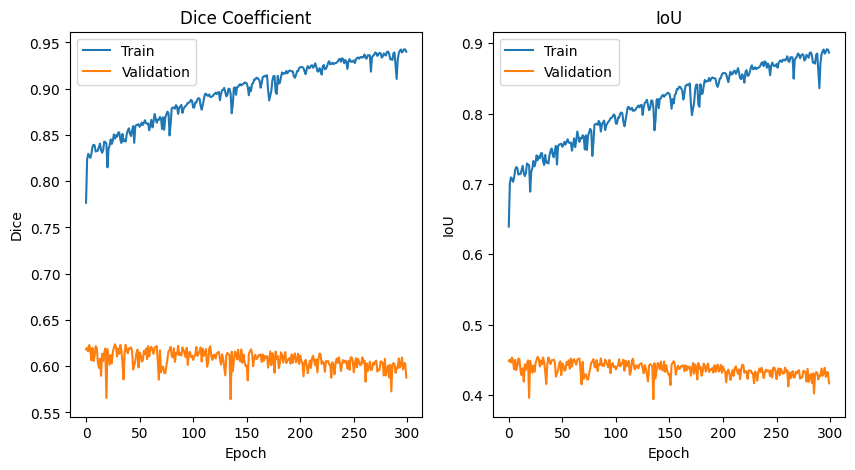

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Dice Coefficient')
plt.ylabel('Dice')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['iou_coef'])
plt.plot(history.history['val_iou_coef'])
plt.title('IoU')
plt.ylabel('IoU')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

find 20%

In [ ]:
import numpy as np

def average_confidence_per_image(y_pred, threshold=0.5):
    """
    Computes the average confidence (probability) for each image in the predictions.
    You can apply a threshold to consider only pixels with higher confidence as foreground.

    Parameters:
    y_pred: Predicted masks from the model (probabilities)
    threshold: The probability threshold to classify pixels as foreground (default 0.5)

    Returns:
    avg_confidences: A list of average confidence scores for each image
    """
    avg_confidences = []

    for pred in y_pred:
        # Flatten the predictions for easier calculation
        pred_flattened = pred.flatten()

        foreground_pixels = pred_flattened[pred_flattened > threshold]  # Get foreground pixels above threshold

        if len(foreground_pixels) > 0:
            avg_confidence = np.mean(foreground_pixels)  # Calculate the average confidence for the foreground pixels
        else:
            avg_confidence = 0  # No foreground pixels with confidence above threshold

        avg_confidences.append(avg_confidence)

    return avg_confidences

# Assuming y_pred contains the raw output probabilities from the model
avg_confidences = average_confidence_per_image(y_pred, threshold=0.5)

# Print the average confidence for the first few images
print("Average Confidence for Test Images:")
for i, avg_conf in enumerate(avg_confidences[:5]):  # Display for the first 5 test images
    print(f"Image {i+1}: Average Confidence = {avg_conf:.4f}")


Average Confidence for Test Images:
Image 1: Average Confidence = 0.9247
Image 2: Average Confidence = 0.8391
Image 3: Average Confidence = 0.8665
Image 4: Average Confidence = 0.9043
Image 5: Average Confidence = 0.8560


In [ ]:
len(avg_confidences)

150

In [ ]:
# Find the indices of the bottom 20% images with the lowest average confidence

import numpy as np

def find_bottom_percentile_indices(avg_confidences, percentile=20):
    """
    Finds the indices of images with the lowest average confidence scores.

    Args:
        avg_confidences: A list or numpy array of average confidence scores.
        percentile: The desired percentile

    Returns:
        A list of indices corresponding to the bottom percentile images.
    """
    # Calculate the threshold for the given percentile
    threshold = np.percentile(avg_confidences, percentile)

    # Find the indices of images with confidence below the threshold
    bottom_indices = np.where(avg_confidences <= threshold)[0]

    return bottom_indices

bottom_20_indices = find_bottom_percentile_indices(avg_confidences, percentile=20)
print(f"Indices of images in the bottom 20% of average confidence: {bottom_20_indices}")

Indices of images in the bottom 20% of average confidence: [  1   2   4   6  18  19  24  30  35  37  38  43  46  51  55  60  62  67
  68  71  76  79  86 107 108 136 137 142 144 149]


In [ ]:
from sklearn.metrics import accuracy_score

# Convert ground truth to binary (same threshold used for prediction)
Y_test_binary = (Y_test > 0.5).astype(np.float32)  # Apply threshold 0.5 to Y_test

# Calculate metrics only for the images in bottom_20_indices
iou_scores_bottom = [iou_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]
dice_scores_bottom = [dice_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]

mean_iou_bottom = np.mean(iou_scores_bottom)
mean_dice_bottom = np.mean(dice_scores_bottom)

# Accuracy calculation for bottom images
y_pred_bottom = model.predict(X_test[bottom_20_indices])
# Threshold y_pred_bottom to get binary predictions for accuracy calculation
y_pred_bottom_binary = (y_pred_bottom > 0.5).astype(np.float32)  # Convert to 0 and 1

# Accuracy based on binary comparison
accuracy_bottom = accuracy_score(Y_test_binary[bottom_20_indices].flatten(), y_pred_bottom_binary.flatten())

print(f"Test Accuracy (Bottom 20%): {accuracy_bottom}")
print(f"Test Dice Coefficient (Bottom 20%): {mean_dice_bottom}")
print(f"Test IoU (Bottom 20%): {mean_iou_bottom}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
Test Accuracy (Bottom 20%): 0.9123453776041667
Test Dice Coefficient (Bottom 20%): 0.33307549357414246
Test IoU (Bottom 20%): 0.23385995626449585




---



**Deep UNET**

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization, LeakyReLU, Dropout, Activation # Import LeakyReLU
from tensorflow.keras.models import Model

def conv_block(x, filters):
    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    #x = LeakyReLU(alpha=0.1)(x)

    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    #x = LeakyReLU(alpha=0.1)(x)

    return x

def unet_model(input_size=(64, 64, 3)):
    inputs = Input(input_size)

    # Downsampling
    conv1 = conv_block(inputs, 64)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = conv_block(pool1, 128)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = conv_block(pool2, 256)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = conv_block(pool3, 512)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    # Bottleneck
    conv5 = conv_block(pool4, 1024)
    #conv5 = Dropout(0.5)(conv5)

    # Upsampling
    up6 = UpSampling2D(size=(2, 2))(conv5)
    merge6 = Concatenate()([conv4, up6])
    conv6 = conv_block(merge6, 512)

    up7 = UpSampling2D(size=(2, 2))(conv6)
    merge7 = Concatenate()([conv3, up7])
    conv7 = conv_block(merge7, 256)

    up8 = UpSampling2D(size=(2, 2))(conv7)
    merge8 = Concatenate()([conv2, up8])
    conv8 = conv_block(merge8, 128)

    up9 = UpSampling2D(size=(2, 2))(conv8)
    merge9 = Concatenate()([conv1, up9])
    conv9 = conv_block(merge9, 64)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    model = Model(inputs=inputs, outputs=outputs)
    return model


In [ ]:
model = unet_model()
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

In [ ]:
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=300, batch_size=32)

Epoch 1/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 31s 566ms/step - accuracy: 0.5600 - dice_coef: 0.3517 - iou_coef: 0.2152 - loss: 0.9128 - val_accuracy: 0.7928 - val_dice_coef: 0.2347 - val_iou_coef: 0.1333 - val_loss: 1.0316
Epoch 2/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7270 - dice_coef: 0.4881 - iou_coef: 0.3237 - loss: 0.7632 - val_accuracy: 0.7928 - val_dice_coef: 0.2102 - val_iou_coef: 0.1177 - val_loss: 1.0557
Epoch 3/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7749 - dice_coef: 0.5481 - iou_coef: 0.3787 - loss: 0.6919 - val_accuracy: 0.7949 - val_dice_coef: 0.2287 - val_iou_coef: 0.1293 - val_loss: 1.0381
Epoch 4/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8153 - dice_coef: 0.5893 - iou_coef: 0.4197 - loss: 0.6405 - val_accuracy: 0.7928 - val_dice_coef: 0.1772 - val_iou_coef: 0.0973 - val_loss: 1.0879
Epoch 5/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8395 - dice_coef: 0.6389 - iou_coef: 0.4712 - loss: 0.5772 - val_accuracy: 0

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 399ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8486 - dice_coef: 0.6597 - iou_coef: 0.4939 - loss: 0.5491
Test Accuracy: 0.8456363677978516
Test Dice Coefficient: 0.6216508746147156
Test IoU: 0.5250946879386902


In [ ]:
from sklearn.metrics import accuracy_score

Y_test_binary = (Y_test > 0.5).astype(np.float32)


iou_scores_bottom = [iou_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]
dice_scores_bottom = [dice_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]

mean_iou_bottom = np.mean(iou_scores_bottom)
mean_dice_bottom = np.mean(dice_scores_bottom)

y_pred_bottom = model.predict(X_test[bottom_20_indices])
y_pred_bottom_binary = (y_pred_bottom > 0.5).astype(np.float32)

accuracy_bottom = accuracy_score(Y_test_binary[bottom_20_indices].flatten(), y_pred_bottom_binary.flatten())


print(f"Test Accuracy (Bottom 20%): {accuracy_bottom}")
print(f"Test Dice Coefficient (Bottom 20%): {mean_dice_bottom}")
print(f"Test IoU (Bottom 20%): {mean_iou_bottom}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Test Accuracy (Bottom 20%): 0.9452718098958334
Test Dice Coefficient (Bottom 20%): 0.49685558676719666
Test IoU (Bottom 20%): 0.4135655164718628


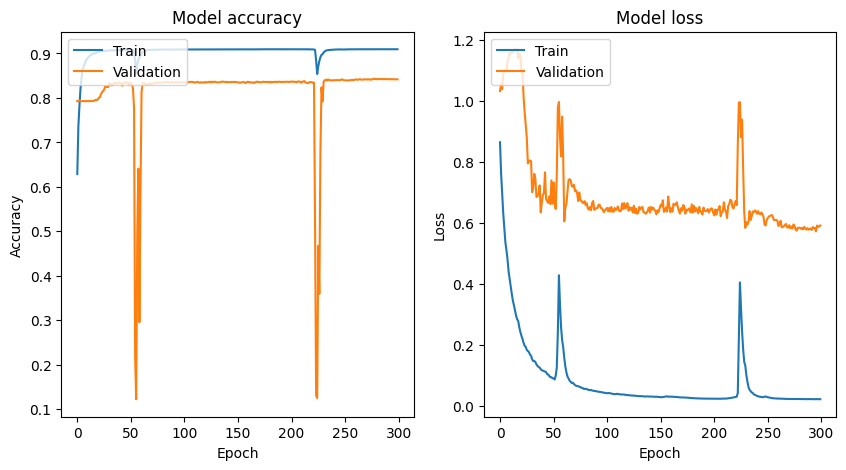

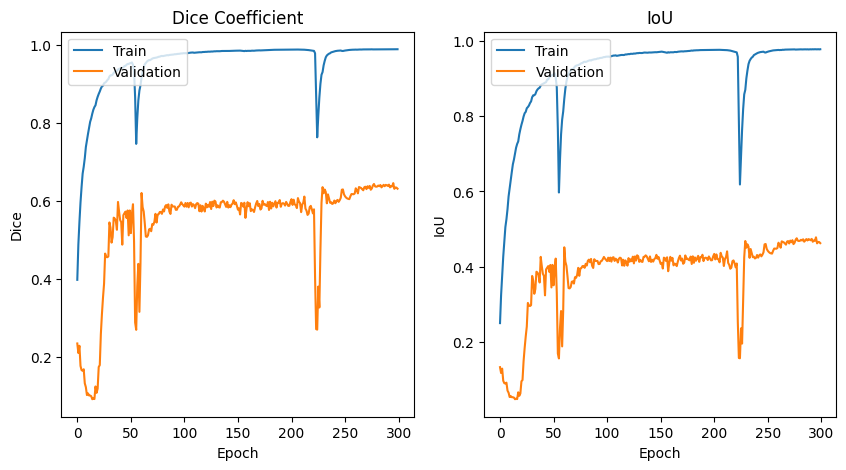

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Dice Coefficient')
plt.ylabel('Dice')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['iou_coef'])
plt.plot(history.history['val_iou_coef'])
plt.title('IoU')
plt.ylabel('IoU')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Deep+UNET AUG

In [ ]:
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

# augmentation
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], additional_targets={'mask': 'mask'})

# Lists to store augmented data
X_aug = []
Y_aug = []

for x, y in zip(X_train, Y_train):

    if y.shape[-1] == 3:  # Mask has 3 channels, likely redundant
        y = y[:, :, 0:1]  # Keep only the first channel (grayscale mask)

    # Ensure mask has 1 channel
    if y.shape[-1] == 1:  # Grayscale mask, should have 1 channel
        y = np.repeat(y, 3, axis=-1)

    print(f"Original image shape: {x.shape}, Original mask shape: {y.shape}")

    # Augment the image and mask
    augmented = augment(image=x, mask=y)
    x_aug = augmented["image"]
    y_aug = augmented["mask"]

    print(f"Augmented image shape: {x_aug.shape}, Augmented mask shape: {y_aug.shape}")


    if y_aug.ndim == 2:  # If it's (H, W)
        y_aug = y_aug[:, :, np.newaxis]  # Add channel dimension: (H, W, 1)
    elif y_aug.ndim == 3 and y_aug.shape[0] < y_aug.shape[-1]:  # If it's (1, H, W)
        y_aug = np.transpose(y_aug, (1, 2, 0))  # Change to (H, W, 1)
    # If it's (H, W, 3) convert it to (H, W, 1)
    elif y_aug.ndim == 3 and y_aug.shape[-1] == 3:
        # Convert y_aug back to single channel (grayscale)
        y_aug = y_aug[:, :, 0:1]

    # Append to lists
    X_aug.append(x_aug)
    Y_aug.append(y_aug)

# Convert to NumPy arrays
X_aug = np.array(X_aug)
Y_aug = np.array(Y_aug)

# Combine with original data
X_train_combined = np.concatenate((X_train, X_aug))
Y_train_combined = np.concatenate((Y_train, Y_aug))


augmented data

In [ ]:
#train augmented data
model.compile(optimizer=Adam(learning_rate=1e-4), loss=combined_loss, metrics=['accuracy', dice_coef, iou_coef])

# Train the model using the combined augmented dataset
history_augmented = model.fit(X_train_combined, Y_train_combined, validation_data=(X_val, Y_val), epochs=10, batch_size=4)


# Evaluate the model on the test set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)

# Calculate metrics
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")


Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.6771 - dice_coef: 0.4172 - iou_coef: 0.2729 - loss: 0.8367 - val_accuracy: 0.7747 - val_dice_coef: 0.4398 - val_iou_coef: 0.2914 - val_loss: 0.8131
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7777 - dice_coef: 0.5179 - iou_coef: 0.3609 - loss: 0.7204 - val_accuracy: 0.7663 - val_dice_coef: 0.5573 - val_iou_coef: 0.3961 - val_loss: 0.6790
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8118 - dice_coef: 0.5954 - iou_coef: 0.4356 - loss: 0.6256 - val_accuracy: 0.8313 - val_dice_coef: 0.6465 - val_iou_coef: 0.4925 - val_loss: 0.5587
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8303 - dice_coef: 0.6441 - iou_coef: 0.4875 - loss: 0.5623 - val_accuracy: 0.8324 - val_dice_coef: 0.6002 - val_iou_coef: 0.4475 - val_loss: 0.6106
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8424 - dice_coef: 0.6806 - iou_coef: 0.5307 - loss: 0.5117 - val_accurac

bottom 20%

In [ ]:
from sklearn.metrics import accuracy_score

# Convert ground truth to binary (same threshold used for prediction)
Y_test_binary = (Y_test > 0.5).astype(np.float32)  # Apply threshold 0.5 to Y_test

# Calculate metrics only for the images in bottom_20_indices
iou_scores_bottom = [iou_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]
dice_scores_bottom = [dice_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]

mean_iou_bottom = np.mean(iou_scores_bottom)
mean_dice_bottom = np.mean(dice_scores_bottom)

# Accuracy calculation for bottom images
y_pred_bottom = model.predict(X_test[bottom_20_indices])
# Threshold y_pred_bottom to get binary predictions for accuracy calculation
y_pred_bottom_binary = (y_pred_bottom > 0.5).astype(np.float32)  # Convert to 0 and 1

# Accuracy based on binary comparison
accuracy_bottom = accuracy_score(Y_test_binary[bottom_20_indices].flatten(), y_pred_bottom_binary.flatten())

# Print the results
print(f"Test Accuracy (Bottom 20%): {accuracy_bottom}")
print(f"Test Dice Coefficient (Bottom 20%): {mean_dice_bottom}")
print(f"Test IoU (Bottom 20%): {mean_iou_bottom}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
Test Accuracy (Bottom 20%): 0.932666015625
Test Dice Coefficient (Bottom 20%): 0.5873931646347046
Test IoU (Bottom 20%): 0.4953638017177582


another run of sam model gave better reslus, though!

In [ ]:

model = unet_model()
model.compile(optimizer=Adam(learning_rate=1e-4),loss=combined_loss, metrics=['accuracy', dice_coef,iou_coef])

# Train Model
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=4)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.6920 - dice_coef: 0.4166 - iou_coef: 0.2718 - loss: 0.6558 - val_accuracy: 0.8025 - val_dice_coef: 0.1031 - val_iou_coef: 0.0544 - val_loss: 0.9213
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.7791 - dice_coef: 0.5276 - iou_coef: 0.3677 - loss: 0.5523 - val_accuracy: 0.8173 - val_dice_coef: 0.3813 - val_iou_coef: 0.2424 - val_loss: 0.6890
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.8221 - dice_coef: 0.5943 - iou_coef: 0.4337 - loss: 0.4860 - val_accuracy: 0.8132 - val_dice_coef: 0.5210 - val_iou_coef: 0.3654 - val_loss: 0.5554
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.8343 - dice_coef: 0.6145 - iou_coef: 0.4550 - loss: 0.4652 - val_accuracy: 0.8253 - val_dice_coef: 0.5511 - val_iou_coef: 0.3933 - val_loss: 0.5292
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.8405 - dice_coef: 0.6359 - iou_coef: 0.4789 - loss: 0.4426 - val_acc

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 431ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.8679 - dice_coef: 0.7482 - iou_coef: 0.5994 - loss: 0.3259
Test Accuracy: 0.8663964867591858
Test Dice Coefficient: 0.7554394602775574
Test IoU: 0.6603864431381226


ATTENTION

Attention Gate block

In [ ]:
from tensorflow.keras.layers import Conv2D, Activation, UpSampling2D, Concatenate, MaxPooling2D, Input, BatchNormalization, multiply, Add
from tensorflow.keras.models import Model

def attention_gate(x, g, inter_channel):
    theta_x = Conv2D(inter_channel, (1, 1), strides=(1, 1), padding='same')(x)
    phi_g = Conv2D(inter_channel, (1, 1), strides=(1, 1), padding='same')(g)

    add_xg = Add()([theta_x, phi_g])
    act_xg = Activation('relu')(add_xg)

    psi = Conv2D(1, (1, 1), strides=(1, 1), padding='same')(act_xg)
    psi = Activation('sigmoid')(psi)

    attn_coefficients = multiply([x, psi])
    return attn_coefficients


Attention UNET Architecture (simple)

In [ ]:
def attention_unet(input_size=(64, 64, 3)):
    inputs = Input(input_size)

    # Encoder
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = BatchNormalization()(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = BatchNormalization()(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = BatchNormalization()(conv3)

    # Decoder
    up1 = UpSampling2D(size=(2, 2))(conv3)
    att1 = attention_gate(conv2, up1, inter_channel=64)
    merge1 = Concatenate()([att1, up1])
    conv4 = Conv2D(128, (3, 3), activation='relu', padding='same')(merge1)
    conv4 = BatchNormalization()(conv4)

    up2 = UpSampling2D(size=(2, 2))(conv4)
    att2 = attention_gate(conv1, up2, inter_channel=32)
    merge2 = Concatenate()([att2, up2])
    conv5 = Conv2D(64, (3, 3), activation='relu', padding='same')(merge2)
    conv5 = BatchNormalization()(conv5)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv5)

    model = Model(inputs, outputs)
    return model


In [ ]:
model = attention_unet(input_size=(64, 64, 3))  # change size as needed


In [ ]:
model.summary()


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_193 (Conv2D) │ (None, 64, 64,    │      1,792 │ input_layer_19[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_193[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_48    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_194 (Conv2D) │ (None, 32, 32,    │     73,856 │ max_pooling2d_48… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_194[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_49    │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_195 (Conv2D) │ (None, 16, 16,    │    295,168 │ max_pooling2d_49… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_195[0][0]  │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_48    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_196 (Conv2D) │ (None, 32, 32,    │      8,256 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_197 (Conv2D) │ (None, 32, 32,    │     16,448 │ up_sampling2d_48… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32, 32,    │          0 │ conv2d_196[0][0], │
│                     │ 64)               │            │ conv2d_197[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_76       │ (None, 32, 32,    │          0 │ add_2[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_198 (Conv2D) │ (None, 32, 32, 1) │         65 │ activation_76[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_77       │ (None, 32, 32, 1) │          0 │ conv2d_198[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 128)              │            │ activation_77[0]

 Total params: 957,603 (3.65 MB)

 Trainable params: 956,323 (3.65 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Import EarlyStopping and ReduceLROnPlateau

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

In [ ]:

history10 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=4)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6341 - dice_coef: 0.4124 - iou_coef: 0.2658 - loss: 0.8445 - val_accuracy: 0.7928 - val_dice_coef: 0.0207 - val_iou_coef: 0.0105 - val_loss: 1.2318
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7162 - dice_coef: 0.4791 - iou_coef: 0.3255 - loss: 0.7663 - val_accuracy: 0.7927 - val_dice_coef: 0.0173 - val_iou_coef: 0.0090 - val_loss: 1.2351
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7338 - dice_coef: 0.4926 - iou_coef: 0.3382 - loss: 0.7500 - val_accuracy: 0.7769 - val_dice_coef: 0.3753 - val_iou_coef: 0.2400 - val_loss: 0.8827
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7498 - dice_coef: 0.5051 - iou_coef: 0.3465 - loss: 0.7376 - val_accuracy: 0.7950 - val_dice_coef: 0.4241 - val_iou_coef: 0.2815 - val_loss: 0.8254
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7628 - dice_coef: 0.5197 - iou_coef: 0.3625 - loss: 0.7183 - val_accuracy: 0

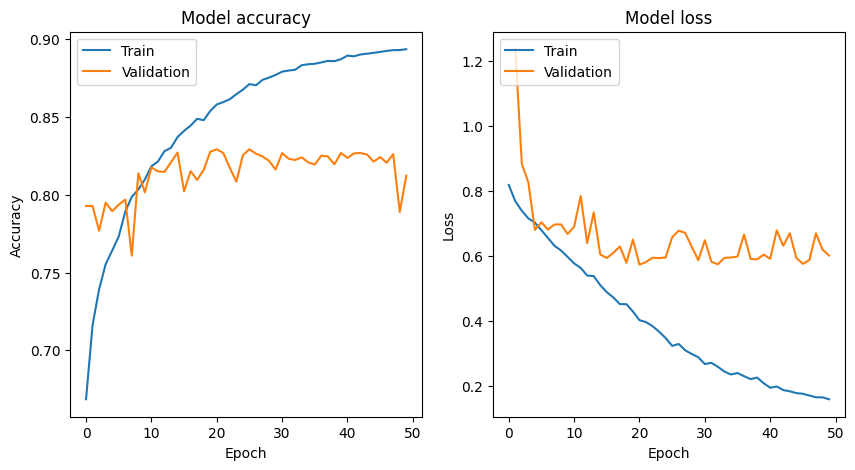

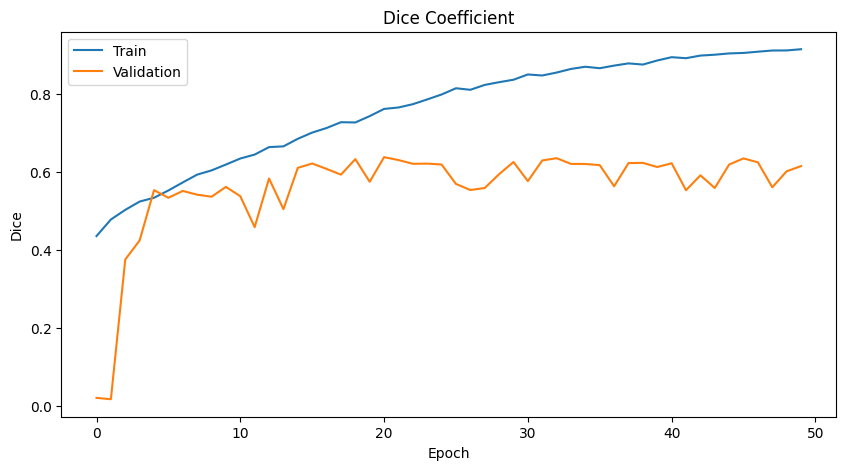

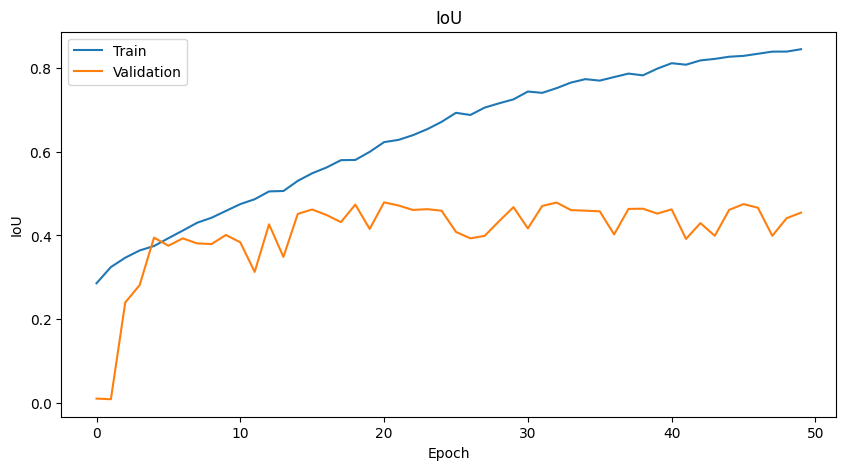

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history10.history['accuracy'])
plt.plot(history10.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history10.history['loss'])
plt.plot(history10.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot Dice Coefficient
plt.figure(figsize=(10, 5))
plt.plot(history10.history['dice_coef'])
plt.plot(history10.history['val_dice_coef'])
plt.title('Dice Coefficient')
plt.ylabel('Dice')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot IoU
plt.figure(figsize=(10, 5))
plt.plot(history10.history['iou_coef'])
plt.plot(history10.history['val_iou_coef'])
plt.title('IoU')
plt.ylabel('IoU')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.8193 - dice_coef: 0.6356 - iou_coef: 0.4666 - loss: 0.5820
Test Accuracy: 0.8182633519172668
Test Dice Coefficient: 0.5946796536445618
Test IoU: 0.46439656615257263


In [ ]:
# fit augmented data+data in to the model


# Compile the model (if not already compiled)
model.compile(optimizer=Adam(learning_rate=1e-4), loss=combined_loss, metrics=['accuracy', dice_coef, iou_coef])

# Train the model using the combined augmented dataset
history_augmented = model.fit(X_train_combined, Y_train_combined, validation_data=(X_val, Y_val), epochs=20, batch_size=4)


# Evaluate the model on the test set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)

# Calculate metrics
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")


Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8888 - dice_coef: 0.8837 - iou_coef: 0.7964 - loss: 0.2108 - val_accuracy: 0.7983 - val_dice_coef: 0.6137 - val_iou_coef: 0.4523 - val_loss: 0.6044
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8902 - dice_coef: 0.8911 - iou_coef: 0.8080 - loss: 0.1984 - val_accuracy: 0.8275 - val_dice_coef: 0.6245 - val_iou_coef: 0.4629 - val_loss: 0.5894
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8919 - dice_coef: 0.8966 - iou_coef: 0.8169 - loss: 0.1891 - val_accuracy: 0.8109 - val_dice_coef: 0.6330 - val_iou_coef: 0.4745 - val_loss: 0.5798
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8911 - dice_coef: 0.8971 - iou_coef: 0.8172 - loss: 0.1885 - val_accuracy: 0.8258 - val_dice_coef: 0.6079 - val_iou_coef: 0.4460 - val_loss: 0.6109
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8942 - dice_coef: 0.9033 - iou_coef: 0.8276 - loss: 0.1776 - val_accuracy: 0

In [ ]:
from sklearn.metrics import accuracy_score

# Convert ground truth to binary (same threshold used for prediction)
Y_test_binary = (Y_test > 0.5).astype(np.float32)  # Apply threshold 0.5 to Y_test

# Calculate metrics only for the images in bottom_20_indices
iou_scores_bottom = [iou_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]
dice_scores_bottom = [dice_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]

mean_iou_bottom = np.mean(iou_scores_bottom)
mean_dice_bottom = np.mean(dice_scores_bottom)

# Accuracy calculation for bottom images
y_pred_bottom = model.predict(X_test[bottom_20_indices])
# Threshold y_pred_bottom to get binary predictions for accuracy calculation
y_pred_bottom_binary = (y_pred_bottom > 0.5).astype(np.float32)  # Convert to 0 and 1

# Accuracy based on binary comparison
accuracy_bottom = accuracy_score(Y_test_binary[bottom_20_indices].flatten(), y_pred_bottom_binary.flatten())

# Print the results
print(f"Test Accuracy (Bottom 20%): {accuracy_bottom}")
print(f"Test Dice Coefficient (Bottom 20%): {mean_dice_bottom}")
print(f"Test IoU (Bottom 20%): {mean_iou_bottom}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
Test Accuracy (Bottom 20%): 0.9263509114583334
Test Dice Coefficient (Bottom 20%): 0.45915305614471436
Test IoU (Bottom 20%): 0.33441945910453796


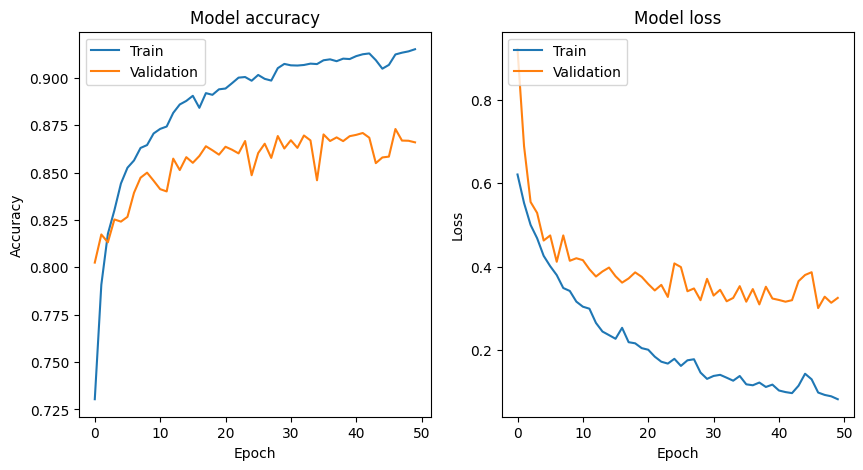

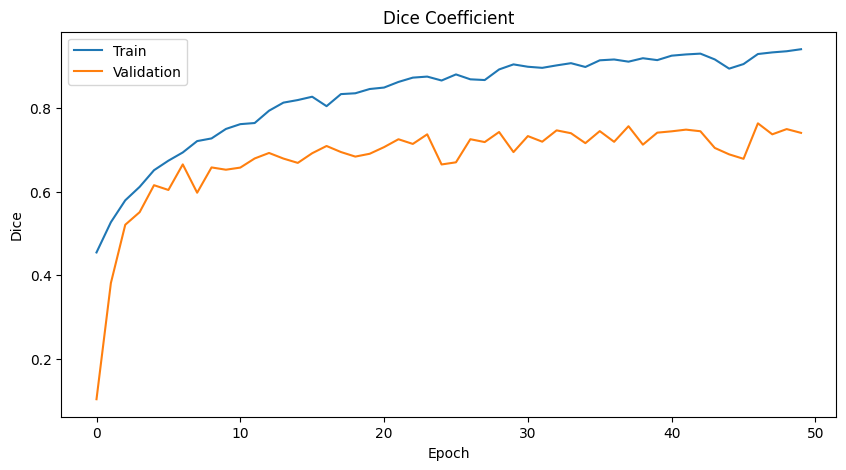

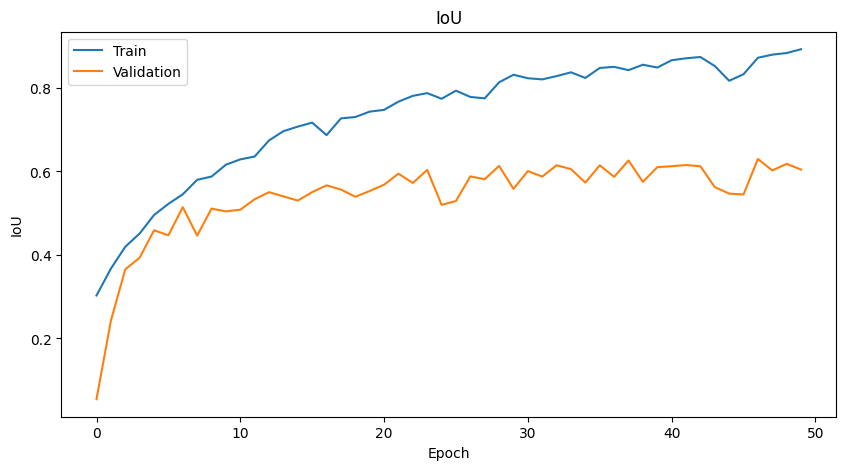

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot Dice Coefficient
plt.figure(figsize=(10, 5))
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Dice Coefficient')
plt.ylabel('Dice')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# Plot IoU
plt.figure(figsize=(10, 5))
plt.plot(history.history['iou_coef'])
plt.plot(history.history['val_iou_coef'])
plt.title('IoU')
plt.ylabel('IoU')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Deep Attention**

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization, LeakyReLU, Activation, multiply, Add
from tensorflow.keras.models import Model

def conv_block(x, filters):
    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    return x

def attention_gate(x, g, inter_channel):
    theta_x = Conv2D(inter_channel, (1, 1), padding='same')(x)
    phi_g = Conv2D(inter_channel, (1, 1), padding='same')(g)
    add_xg = Add()([theta_x, phi_g])
    act_xg = Activation('relu')(add_xg)
    psi = Conv2D(1, (1, 1), padding='same')(act_xg)
    psi = Activation('sigmoid')(psi)
    attn_out = multiply([x, psi])
    return attn_out

def attention_unet(input_size=(64, 64, 3)):
    inputs = Input(input_size)

    # Encoder
    conv1 = conv_block(inputs, 64)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = conv_block(pool1, 128)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = conv_block(pool2, 256)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = conv_block(pool3, 512)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    # Bottleneck
    conv5 = conv_block(pool4, 1024)

    # Decoder with attention
    up6 = UpSampling2D(size=(2, 2))(conv5)
    att4 = attention_gate(conv4, up6, inter_channel=512)
    merge6 = Concatenate()([att4, up6])
    conv6 = conv_block(merge6, 512)

    up7 = UpSampling2D(size=(2, 2))(conv6)
    att3 = attention_gate(conv3, up7, inter_channel=256)
    merge7 = Concatenate()([att3, up7])
    conv7 = conv_block(merge7, 256)

    up8 = UpSampling2D(size=(2, 2))(conv7)
    att2 = attention_gate(conv2, up8, inter_channel=128)
    merge8 = Concatenate()([att2, up8])
    conv8 = conv_block(merge8, 128)

    up9 = UpSampling2D(size=(2, 2))(conv8)
    att1 = attention_gate(conv1, up9, inter_channel=64)
    merge9 = Concatenate()([att1, up9])
    conv9 = conv_block(merge9, 64)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    model = Model(inputs=inputs, outputs=outputs)
    return model


In [ ]:
model = attention_unet(input_size=(64, 64, 3))  # change size as needed


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

In [ ]:
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=4)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.6645 - dice_coef: 0.4226 - iou_coef: 0.2766 - loss: 0.8312 - val_accuracy: 0.7928 - val_dice_coef: 0.0955 - val_iou_coef: 0.0502 - val_loss: 1.1646
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7544 - dice_coef: 0.4914 - iou_coef: 0.3349 - loss: 0.7531 - val_accuracy: 0.8054 - val_dice_coef: 0.3631 - val_iou_coef: 0.2268 - val_loss: 0.8989
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7811 - dice_coef: 0.5372 - iou_coef: 0.3772 - loss: 0.6985 - val_accuracy: 0.8055 - val_dice_coef: 0.4642 - val_iou_coef: 0.3175 - val_loss: 0.7786
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8093 - dice_coef: 0.5846 - iou_coef: 0.4242 - loss: 0.6395 - val_accuracy: 0.7602 - val_dice_coef: 0.5462 - val_iou_coef: 0.3845 - val_loss: 0.6885
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8305 - dice_coef: 0.6391 - iou_coef: 0.4803 - loss: 0.5702 - val_accurac

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 570ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 0.8583 - dice_coef: 0.7381 - iou_coef: 0.5867 - loss: 0.4406
Test Accuracy: 0.8563802242279053
Test Dice Coefficient: 0.7225894927978516
Test IoU: 0.6370233297348022


In [ ]:
model = attention_unet_strided(input_size=(64, 64, 3))  # change size as needed

<ipython-input-29-18549f8b950e>:27: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet', alpha=0.35)


In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

**Deep Att +Aug**

In [ ]:

# Compile the model (if not already compiled)
model.compile(optimizer=Adam(learning_rate=1e-4), loss=combined_loss, metrics=['accuracy', dice_coef, iou_coef])

# Train the model using the combined augmented dataset
history_augmented = model.fit(X_train_combined, Y_train_combined, validation_data=(X_val, Y_val), epochs=20, batch_size=4)


# Evaluate the model on the test set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)

# Calculate metrics
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")


Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.8755 - dice_coef: 0.8221 - iou_coef: 0.7115 - loss: 0.3053 - val_accuracy: 0.8556 - val_dice_coef: 0.7287 - val_iou_coef: 0.5949 - val_loss: 0.4374
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8800 - dice_coef: 0.8409 - iou_coef: 0.7370 - loss: 0.2768 - val_accuracy: 0.8563 - val_dice_coef: 0.7391 - val_iou_coef: 0.6058 - val_loss: 0.4264
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8786 - dice_coef: 0.8324 - iou_coef: 0.7241 - loss: 0.2907 - val_accuracy: 0.8495 - val_dice_coef: 0.7357 - val_iou_coef: 0.6021 - val_loss: 0.4292
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8836 - dice_coef: 0.8539 - iou_coef: 0.7583 - loss: 0.2543 - val_accuracy: 0.8562 - val_dice_coef: 0.7381 - val_iou_coef: 0.6062 - val_loss: 0.4240
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8803 - dice_coef: 0.8480 - iou_coef: 0.7500 - loss: 0.2635 - val_accurac

In [ ]:
from sklearn.metrics import accuracy_score

# Convert ground truth to binary (same threshold used for prediction)
Y_test_binary = (Y_test > 0.5).astype(np.float32)  # Apply threshold 0.5 to Y_test

# Calculate metrics only for the images in bottom_20_indices
iou_scores_bottom = [iou_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]
dice_scores_bottom = [dice_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]

mean_iou_bottom = np.mean(iou_scores_bottom)
mean_dice_bottom = np.mean(dice_scores_bottom)

# Accuracy calculation for bottom images
y_pred_bottom = model.predict(X_test[bottom_20_indices])
# Threshold y_pred_bottom to get binary predictions for accuracy calculation
y_pred_bottom_binary = (y_pred_bottom > 0.5).astype(np.float32)  # Convert to 0 and 1

# Accuracy based on binary comparison
accuracy_bottom = accuracy_score(Y_test_binary[bottom_20_indices].flatten(), y_pred_bottom_binary.flatten())

# Print the results
print(f"Test Accuracy (Bottom 20%): {accuracy_bottom}")
print(f"Test Dice Coefficient (Bottom 20%): {mean_dice_bottom}")
print(f"Test IoU (Bottom 20%): {mean_iou_bottom}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Test Accuracy (Bottom 20%): 0.9399332682291667
Test Dice Coefficient (Bottom 20%): 0.5953708291053772
Test IoU (Bottom 20%): 0.5124533176422119


**Pretrained+att+fine tune**

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Conv2D, Input, UpSampling2D, Concatenate, BatchNormalization, LeakyReLU, Activation, multiply, Add
from tensorflow.keras.models import Model

def conv_block(x, filters):
    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    return x

def attention_gate(x, g, inter_channel):
    theta_x = Conv2D(inter_channel, (1, 1), padding='same')(x)
    phi_g = Conv2D(inter_channel, (1, 1), padding='same')(g)
    add_xg = Add()([theta_x, phi_g])
    act_xg = Activation('relu')(add_xg)
    psi = Conv2D(1, (1, 1), padding='same')(act_xg)
    psi = Activation('sigmoid')(psi)
    return multiply([x, psi])

def attention_unet_pretrained(input_size=(64, 64, 3)):
    inputs = Input(input_size)

    # Pretrained encoder: EfficientNetB0 (changeable)
    base_model = EfficientNetB0(include_top=False, input_tensor=inputs, weights='imagenet')

    # Extract encoder blocks
    c1 = base_model.get_layer('block1a_activation').output  # ~64x64
    c2 = base_model.get_layer('block2b_add').output         # ~32x32
    c3 = base_model.get_layer('block3b_add').output         # ~16x16
    c4 = base_model.get_layer('block4c_add').output         # ~8x8
    c5 = base_model.get_layer('top_activation').output # Changed to 'top_activation'

    # Decoder
    up1 = UpSampling2D()(c5)
    att4 = attention_gate(c4, up1, inter_channel=256)
    merge1 = Concatenate()([att4, up1])
    d1 = conv_block(merge1, 256)

    up2 = UpSampling2D()(d1)
    att3 = attention_gate(c3, up2, inter_channel=128)
    merge2 = Concatenate()([att3, up2])
    d2 = conv_block(merge2, 128)

    up3 = UpSampling2D()(d2)
    att2 = attention_gate(c2, up3, inter_channel=64)
    merge3 = Concatenate()([att2, up3])
    d3 = conv_block(merge3, 64)

    up4 = UpSampling2D()(d3)
    att1 = attention_gate(c1, up4, inter_channel=32)
    merge4 = Concatenate()([att1, up4])
    d4 = conv_block(merge4, 32)

    up5 = UpSampling2D()(d4)
    d5 = conv_block(up5, 16)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(d5)


    model = Model(inputs=inputs, outputs=outputs)
    return model


In [ ]:
model = attention_unet_pretrained(input_size=(64, 64, 3))  # change size as needed


In [ ]:
for layer in model.layers:
    layer.trainable = True

# Re-compile with a lower learning rate
from tensorflow.keras.optimizers import Adam

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

In [ ]:

history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=4)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 115s 114ms/step - accuracy: 0.5045 - dice_coef: 0.3180 - iou_coef: 0.1944 - loss: 0.9451 - val_accuracy: 0.7925 - val_dice_coef: 0.1988 - val_iou_coef: 0.1112 - val_loss: 1.0673
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7284 - dice_coef: 0.4250 - iou_coef: 0.2758 - loss: 0.8306 - val_accuracy: 0.7928 - val_dice_coef: 0.1285 - val_iou_coef: 0.0689 - val_loss: 1.1341
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7586 - dice_coef: 0.4588 - iou_coef: 0.3051 - loss: 0.7918 - val_accuracy: 0.7889 - val_dice_coef: 0.2353 - val_iou_coef: 0.1350 - val_loss: 1.0315
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7801 - dice_coef: 0.4905 - iou_coef: 0.3357 - loss: 0.7530 - val_accuracy: 0.7088 - val_dice_coef: 0.4179 - val_iou_coef: 0.2698 - val_loss: 0.8409
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8038 - dice_coef: 0.5114 - iou_coef: 0.3525 - loss: 0.7299 - val_accur

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8122 - dice_coef: 0.3009 - iou_coef: 0.1777 - loss: 0.9660
Test Accuracy: 0.8072558641433716
Test Dice Coefficient: 0.22864104807376862
Test IoU: 0.17756718397140503


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Conv2D, UpSampling2D, Concatenate, BatchNormalization, Activation
from tensorflow.keras.models import Model

def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def unet_mobilenetv2_64(input_size=(64, 64, 3)):
    inputs = Input(input_size)

    # Load MobileNetV2 backbone with shallow depth to keep 4x4 minimum
    backbone = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet', alpha=0.35)

    # Choose mid-depth layers (avoid deepest ones)
    skip1 = backbone.get_layer('block_1_expand_relu').output   # 32x32
    skip2 = backbone.get_layer('block_3_expand_relu').output   # 16x16
    skip3 = backbone.get_layer('block_6_expand_relu').output   # 8x8
    bottleneck = backbone.get_layer('block_10_project').output # ~4x4

    # Decoder
    x = UpSampling2D()(bottleneck)
    x = Concatenate()([x, skip3])
    x = conv_block(x, 128)

    x = UpSampling2D()(x)
    x = Concatenate()([x, skip2])
    x = conv_block(x, 64)

    x = UpSampling2D()(x)
    x = Concatenate()([x, skip1])
    x = conv_block(x, 32)

    x = UpSampling2D()(x)
    x = conv_block(x, 16)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model


In [ ]:
model = unet_mobilenetv2_64()

<ipython-input-317-f20edaa3d4b6>:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet', alpha=0.35)


In [ ]:
# Freeze all layers first
for layer in model.layers:
    layer.trainable = False

# Unfreeze decoder layers (everything after the backbone)
set_trainable = False
for layer in model.layers:
    if isinstance(layer, UpSampling2D) or isinstance(layer, Conv2D):
        set_trainable = True
    if set_trainable:
        layer.trainable = True

In [ ]:

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

In [ ]:
model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=200, batch_size=32)


Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9033 - dice_coef: 0.8577 - iou_coef: 0.7520 - loss: 0.2572 - val_accuracy: 0.8397 - val_dice_coef: 0.5760 - val_iou_coef: 0.4069 - val_loss: 0.6648
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9041 - dice_coef: 0.8577 - iou_coef: 0.7517 - loss: 0.2574 - val_accuracy: 0.8399 - val_dice_coef: 0.5798 - val_iou_coef: 0.4106 - val_loss: 0.6602
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9021 - dice_coef: 0.8708 - iou_coef: 0.7716 - loss: 0.2359 - val_accuracy: 0.8280 - val_dice_coef: 0.6194 - val_iou_coef: 0.4497 - val_loss: 0.6071
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9038 - dice_coef: 0.8682 - iou_coef: 0.7677 - loss: 0.2402 - val_accuracy: 0.8382 - val_dice_coef: 0.5616 - val_iou_coef: 0.3928 - val_loss: 0.6828
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9048 - dice_coef: 0.8615 - iou_coef: 0.7574 - loss: 0.2512 - val_accuracy: 0.8

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 662ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8441 - dice_coef: 0.6915 - iou_coef: 0.5289 - loss: 0.5081
Test Accuracy: 0.8427425026893616
Test Dice Coefficient: 0.6471046209335327
Test IoU: 0.5319547057151794


In [ ]:
#Aug data



# Compile the model (if not already compiled)
model.compile(optimizer=Adam(learning_rate=1e-4), loss=combined_loss, metrics=['accuracy', dice_coef, iou_coef])

# Train the model using the combined augmented dataset
history_augmented = model.fit(X_train_combined, Y_train_combined, validation_data=(X_val, Y_val), epochs=30, batch_size=4)


# Evaluate the model on the test set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)

# Calculate metrics
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")


Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.9061 - dice_coef: 0.9593 - iou_coef: 0.9227 - loss: 0.0783 - val_accuracy: 0.8520 - val_dice_coef: 0.7331 - val_iou_coef: 0.5904 - val_loss: 0.4429
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9069 - dice_coef: 0.9607 - iou_coef: 0.9248 - loss: 0.0761 - val_accuracy: 0.8397 - val_dice_coef: 0.6048 - val_iou_coef: 0.4565 - val_loss: 0.6045
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9062 - dice_coef: 0.9530 - iou_coef: 0.9113 - loss: 0.0900 - val_accuracy: 0.8495 - val_dice_coef: 0.7326 - val_iou_coef: 0.5878 - val_loss: 0.4438
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9058 - dice_coef: 0.9599 - iou_coef: 0.9235 - loss: 0.0775 - val_accuracy: 0.8530 - val_dice_coef: 0.7322 - val_iou_coef: 0.5896 - val_loss: 0.4414
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9043 - dice_coef: 0.9630 - iou_coef: 0.9290 - loss: 0.0718 - val_accurac

In [ ]:
from sklearn.metrics import accuracy_score

# Convert ground truth to binary (same threshold used for prediction)
Y_test_binary = (Y_test > 0.5).astype(np.float32)  # Apply threshold 0.5 to Y_test

# Calculate metrics only for the images in bottom_20_indices
iou_scores_bottom = [iou_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]
dice_scores_bottom = [dice_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]

mean_iou_bottom = np.mean(iou_scores_bottom)
mean_dice_bottom = np.mean(dice_scores_bottom)

# Accuracy calculation for bottom images
y_pred_bottom = model.predict(X_test[bottom_20_indices])
# Threshold y_pred_bottom to get binary predictions for accuracy calculation
y_pred_bottom_binary = (y_pred_bottom > 0.5).astype(np.float32)  # Convert to 0 and 1

# Accuracy based on binary comparison
accuracy_bottom = accuracy_score(Y_test_binary[bottom_20_indices].flatten(), y_pred_bottom_binary.flatten())

# Print the results
print(f"Test Accuracy (Bottom 20%): {accuracy_bottom}")
print(f"Test Dice Coefficient (Bottom 20%): {mean_dice_bottom}")
print(f"Test IoU (Bottom 20%): {mean_iou_bottom}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Test Accuracy (Bottom 20%): 0.9275553385416667
Test Dice Coefficient (Bottom 20%): 0.4248238503932953
Test IoU (Bottom 20%): 0.3313160836696625


Attention U-Net with Pretrained MobileNetV2 + Strided/Transposed Convs

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Concatenate, BatchNormalization, LeakyReLU, Activation, multiply, Add
from tensorflow.keras.models import Model

def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    return x

def attention_gate(x, g, inter_channel):
    theta_x = Conv2D(inter_channel, 1, padding='same')(x)
    phi_g = Conv2D(inter_channel, 1, padding='same')(g)
    add_xg = Add()([theta_x, phi_g])
    act_xg = Activation('relu')(add_xg)
    psi = Conv2D(1, 1, padding='same')(act_xg)
    psi = Activation('sigmoid')(psi)
    return multiply([x, psi])

def attention_unet_strided(input_size=(64, 64, 3)):
    inputs = Input(input_size)

    # Pretrained MobileNetV2 encoder
    base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet', alpha=0.35)

    # Encoder feature maps
    c1 = base_model.get_layer('block_1_expand_relu').output   # 32x32
    c2 = base_model.get_layer('block_3_expand_relu').output   # 16x16
    c3 = base_model.get_layer('block_6_expand_relu').output   # 8x8
    c4 = base_model.get_layer('block_10_project').output      # 4x4

    # Bottleneck: now 1024 filters
    b = conv_block(c4, 1024)

    # Decoder with attention and transposed convs
    d1 = Conv2DTranspose(512, 3, strides=(2, 2), padding='same')(b)  # 4→8
    a3 = attention_gate(c3, d1, inter_channel=256)
    m1 = Concatenate()([a3, d1])
    d1 = conv_block(m1, 512)

    d2 = Conv2DTranspose(256, 3, strides=(2, 2), padding='same')(d1)  # 8→16
    a2 = attention_gate(c2, d2, inter_channel=128)
    m2 = Concatenate()([a2, d2])
    d2 = conv_block(m2, 256)

    d3 = Conv2DTranspose(128, 3, strides=(2, 2), padding='same')(d2)  # 16→32
    a1 = attention_gate(c1, d3, inter_channel=64)
    m3 = Concatenate()([a1, d3])
    d3 = conv_block(m3, 128)

    d4 = Conv2DTranspose(64, 3, strides=(2, 2), padding='same')(d3)  # 32→64
    d4 = conv_block(d4, 64)

    outputs = Conv2D(1, 1, activation='sigmoid')(d4)

    model = Model(inputs, outputs)
    return model


In [ ]:
model = attention_unet_strided()

<ipython-input-36-18549f8b950e>:27: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet', alpha=0.35)


In [ ]:
for layer in model.layers:
    layer.trainable = True

In [ ]:
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=4)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 0.6450 - dice_coef: 0.3989 - iou_coef: 0.2576 - loss: 0.8573 - val_accuracy: 0.3824 - val_dice_coef: 0.3334 - val_iou_coef: 0.2052 - val_loss: 0.9303
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7906 - dice_coef: 0.5566 - iou_coef: 0.3943 - loss: 0.6760 - val_accuracy: 0.7833 - val_dice_coef: 0.5604 - val_iou_coef: 0.3972 - val_loss: 0.6743
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8236 - dice_coef: 0.5963 - iou_coef: 0.4377 - loss: 0.6236 - val_accuracy: 0.7776 - val_dice_coef: 0.5814 - val_iou_coef: 0.4185 - val_loss: 0.6495
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8328 - dice_coef: 0.6578 - iou_coef: 0.5005 - loss: 0.5457 - val_accuracy: 0.7802 - val_dice_coef: 0.5838 - val_iou_coef: 0.4214 - val_loss: 0.6456
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8460 - dice_coef: 0.6979 - iou_coef: 0.5464 - loss: 0.4913 - val_accurac

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

1/5 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 655ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 479ms/step - accuracy: 0.8469 - dice_coef: 0.6945 - iou_coef: 0.5330 - loss: 0.5041
Test Accuracy: 0.8463069796562195
Test Dice Coefficient: 0.6726177930831909
Test IoU: 0.5718004107475281


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Concatenate, BatchNormalization, LeakyReLU, Activation, multiply, Add
from tensorflow.keras.models import Model

def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    return x

def attention_gate(x, g, inter_channel):
    theta_x = Conv2D(inter_channel, 1, padding='same')(x)
    phi_g = Conv2D(inter_channel, 1, padding='same')(g)
    add_xg = Add()([theta_x, phi_g])
    act_xg = Activation('relu')(add_xg)
    psi = Conv2D(1, 1, padding='same')(act_xg)
    psi = Activation('sigmoid')(psi)
    return multiply([x, psi])

def attention_unet_strided(input_size=(64, 64, 3)):
    inputs = Input(input_size)

    # Pretrained MobileNetV2 encoder
    base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet', alpha=0.35)

    # Encoder feature maps
    c1 = base_model.get_layer('block_1_expand_relu').output   # 32x32
    c2 = base_model.get_layer('block_3_expand_relu').output   # 16x16
    c3 = base_model.get_layer('block_6_expand_relu').output   # 8x8
    c4 = base_model.get_layer('block_10_project').output      # 4x4

    # Bottleneck: a deeper conv block
    b = conv_block(c4, 256)

    # Decoder with attention and transposed convs
    d1 = Conv2DTranspose(128, 3, strides=(2, 2), padding='same')(b)  # 4→8
    a3 = attention_gate(c3, d1, inter_channel=128)
    m1 = Concatenate()([a3, d1])
    d1 = conv_block(m1, 128)

    d2 = Conv2DTranspose(64, 3, strides=(2, 2), padding='same')(d1)  # 8→16
    a2 = attention_gate(c2, d2, inter_channel=64)
    m2 = Concatenate()([a2, d2])
    d2 = conv_block(m2, 64)

    d3 = Conv2DTranspose(32, 3, strides=(2, 2), padding='same')(d2)  # 16→32
    a1 = attention_gate(c1, d3, inter_channel=32)
    m3 = Concatenate()([a1, d3])
    d3 = conv_block(m3, 32)

    d4 = Conv2DTranspose(16, 3, strides=(2, 2), padding='same')(d3)  # 32→64
    d4 = conv_block(d4, 16)

    outputs = Conv2D(1, 1, activation='sigmoid')(d4)

    model = Model(inputs, outputs)
    return model


In [ ]:
model = attention_unet_strided()

<ipython-input-22-06426b30d791>:27: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet', alpha=0.35)


2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

In [ ]:
model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=200, batch_size=32)


Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.2201 - dice_coef: 0.2592 - iou_coef: 0.1495 - loss: 1.0083 - val_accuracy: 0.1160 - val_dice_coef: 0.2624 - val_iou_coef: 0.1515 - val_loss: 1.0038
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5505 - dice_coef: 0.3387 - iou_coef: 0.2043 - loss: 0.9275 - val_accuracy: 0.1166 - val_dice_coef: 0.2916 - val_iou_coef: 0.1713 - val_loss: 0.9741
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6953 - dice_coef: 0.3806 - iou_coef: 0.2363 - loss: 0.8824 - val_accuracy: 0.1530 - val_dice_coef: 0.3011 - val_iou_coef: 0.1780 - val_loss: 0.9642
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7426 - dice_coef: 0.4244 - iou_coef: 0.2703 - loss: 0.8351 - val_accuracy: 0.3058 - val_dice_coef: 0.3231 - val_iou_coef: 0.1936 - val_loss: 0.9416
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7803 - dice_coef: 0.4515 - iou_coef: 0.2923 - loss: 0.8050 - val_accuracy: 0.37

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8489 - dice_coef: 0.6704 - iou_coef: 0.5047 - loss: 0.5373
Test Accuracy: 0.8473014235496521
Test Dice Coefficient: 0.6165148019790649
Test IoU: 0.513995885848999


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, Concatenate, BatchNormalization, LeakyReLU, Activation, Add, multiply
from tensorflow.keras.models import Model

def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    return x

def attention_gate(x, g, inter_channel):
    theta_x = Conv2D(inter_channel, 1, padding='same')(x)
    phi_g = Conv2D(inter_channel, 1, padding='same')(g)
    add = Add()([theta_x, phi_g])
    act = Activation('relu')(add)
    psi = Conv2D(1, 1, padding='same')(act)
    psi = Activation('sigmoid')(psi)
    # Original: return multiply([x, psi])  # This is the problematic line
    # Modified:
    return multiply([x, psi])  # Ensures correct output shape

def attention_unet_resnet50_small(input_size=(64, 64, 3)):
    inputs = Input(input_size)

    # Truncated ResNet50 backbone
    base = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)

    # Shallow encoder levels (avoid over-downsampling)
    c1 = base.get_layer("conv1_relu").output             # 32x32
    c2 = base.get_layer("conv2_block3_out").output       # 16x16
    c3 = base.get_layer("conv3_block4_out").output       # 8x8
    b  = base.get_layer("conv4_block2_out").output       # 4x4 bottleneck (stopping here)

    # Decoder
    d1 = Conv2DTranspose(256, 3, strides=2, padding='same')(b)
    a3 = attention_gate(c3, d1, inter_channel=128)
    m1 = Concatenate()([a3, d1])
    d1 = conv_block(m1, 256)

    d2 = Conv2DTranspose(128, 3, strides=2, padding='same')(d1)
    a2 = attention_gate(c2, d2, inter_channel=64)
    m2 = Concatenate()([a2, d2])
    d2 = conv_block(m2, 128)

    d3 = Conv2DTranspose(64, 3, strides=2, padding='same')(d2)
    a1 = attention_gate(c1, d3, inter_channel=32)
    m3 = Concatenate()([a1, d3])
    d3 = conv_block(m3, 64)

    d4 = Conv2DTranspose(32, 3, strides=2, padding='same')(d3)  # 32x32 → 64x64
    d4 = conv_block(d4, 32)

    outputs = Conv2D(1, 1, activation='sigmoid')(d4)

    return Model(inputs, outputs)


In [ ]:
model = attention_unet_resnet50_small()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])

In [ ]:
history=model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=200, batch_size=32)


Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.3025 - dice_coef: 0.2910 - iou_coef: 0.1709 - loss: 0.9764 - val_accuracy: 0.1166 - val_dice_coef: 0.2723 - val_iou_coef: 0.1582 - val_loss: 0.9939
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6839 - dice_coef: 0.4247 - iou_coef: 0.2707 - loss: 0.8347 - val_accuracy: 0.1159 - val_dice_coef: 0.2859 - val_iou_coef: 0.1675 - val_loss: 0.9799
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8145 - dice_coef: 0.4987 - iou_coef: 0.3329 - loss: 0.7510 - val_accuracy: 0.7854 - val_dice_coef: 0.2290 - val_iou_coef: 0.1297 - val_loss: 1.0370
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8429 - dice_coef: 0.5312 - iou_coef: 0.3647 - loss: 0.7109 - val_accuracy: 0.7883 - val_dice_coef: 0.2171 - val_iou_coef: 0.1221 - val_loss: 1.0489
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8616 - dice_coef: 0.5616 - iou_coef: 0.3914 - loss: 0.6756 - val_accuracy: 0.79

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 726ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8587 - dice_coef: 0.7386 - iou_coef: 0.5859 - loss: 0.4421
Test Accuracy: 0.8573567867279053
Test Dice Coefficient: 0.7079396843910217
Test IoU: 0.6134393215179443




---



END for the final



---



Midterm

Dice LOss

In [ ]:
def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Compile the model with Dice Loss
model.compile(optimizer=Adam(learning_rate=1e-4), loss=dice_loss, metrics=['accuracy', dice_coef])
# Train Model
history11 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=10, batch_size=4)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8415 - dice_coef: 0.6582 - loss: 0.3417 - val_accuracy: 0.8339 - val_dice_coef: 0.5744 - val_loss: 0.4245
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8528 - dice_coef: 0.6919 - loss: 0.3080 - val_accuracy: 0.8284 - val_dice_coef: 0.4958 - val_loss: 0.5014
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8610 - dice_coef: 0.7266 - loss: 0.2734 - val_accuracy: 0.8105 - val_dice_coef: 0.5996 - val_loss: 0.4015
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8607 - dice_coef: 0.7297 - loss: 0.2702 - val_accuracy: 0.8318 - val_dice_coef: 0.5020 - val_loss: 0.4956
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8660 - dice_coef: 0.7364 - loss: 0.2635 - val_accuracy: 0.8285 - val_dice_coef: 0.6036 - val_loss: 0.3961
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8653 - dice_coef: 0.7340 - loss: 0.2660 - val_accuracy: 0.8219 - va

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.8258 - dice_coef: 0.6396 - loss: 0.3604
Test Accuracy: 0.8251237273216248
Test Dice Coefficient: 0.6050207614898682
Test IoU: 0.474733829498291


Pretrained+fine Tuned

BCE + DICE

In [ ]:
from tensorflow.keras.losses import binary_crossentropy # Import binary_crossentropy

def combined_loss(y_true, y_pred):
    return 0.3 * binary_crossentropy(y_true, y_pred) + 0.7 * dice_loss(y_true, y_pred)

model.compile(optimizer=Adam(learning_rate=1e-4), loss=combined_loss, metrics=['accuracy', dice_coef])
history12 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=10, batch_size=4)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.8813 - dice_coef: 0.7768 - loss: 0.2846 - val_accuracy: 0.8339 - val_dice_coef: 0.5071 - val_loss: 0.5135
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8811 - dice_coef: 0.7850 - loss: 0.2350 - val_accuracy: 0.8399 - val_dice_coef: 0.5665 - val_loss: 0.4643
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8820 - dice_coef: 0.7971 - loss: 0.2148 - val_accuracy: 0.8351 - val_dice_coef: 0.5593 - val_loss: 0.4675
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8882 - dice_coef: 0.8111 - loss: 0.1936 - val_accuracy: 0.8320 - val_dice_coef: 0.5414 - val_loss: 0.4838
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8914 - dice_coef: 0.8206 - loss: 0.1832 - val_accuracy: 0.8347 - val_dice_coef: 0.5792 - val_loss: 0.4513
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8900 - dice_coef: 0.8277 - loss: 0.1753 - val_accuracy: 0.8366 - va

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

1/5 ━━━━━━━━━━━━━━━━━━━━ 3s 750ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.8418 - dice_coef: 0.5726 - loss: 0.4561
Test Accuracy: 0.8394710421562195
Test Dice Coefficient: 0.5426769256591797
Test IoU: 0.4140889346599579


IOU Loss

In [ ]:
# Compile the Model with IoU Loss
model.compile(optimizer=Adam(learning_rate=1e-4), loss=iou_loss, metrics=['accuracy',iou_coef])
history13 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=10, batch_size=4)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.8978 - iou_coef: 0.7741 - loss: 0.2259 - val_accuracy: 0.8361 - val_iou_coef: 0.3724 - val_loss: 0.6269
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9025 - iou_coef: 0.7812 - loss: 0.2188 - val_accuracy: 0.8139 - val_iou_coef: 0.4598 - val_loss: 0.5427
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9058 - iou_coef: 0.7813 - loss: 0.2187 - val_accuracy: 0.8363 - val_iou_coef: 0.4581 - val_loss: 0.5427
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9028 - iou_coef: 0.8002 - loss: 0.1998 - val_accuracy: 0.8319 - val_iou_coef: 0.4625 - val_loss: 0.5389
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9024 - iou_coef: 0.8126 - loss: 0.1874 - val_accuracy: 0.8378 - val_iou_coef: 0.4286 - val_loss: 0.5708
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9075 - iou_coef: 0.8344 - loss: 0.1656 - val_accuracy: 0.8351 - val_iou_coef:

In [ ]:
# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.8419 - iou_coef: 0.4589 - loss: 0.5409
Test Accuracy: 0.8409261107444763
Test Dice Coefficient: 0.5959197878837585
Test IoU: 0.4630989730358124




---



In [ ]:
import numpy as np
import tensorflow.keras.backend as K

# Compute IoU (Intersection over Union)
def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Compute Dice Coefficient
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.8217 - dice_coef: 0.3829 - loss: 0.2954
Test Accuracy: 0.8165364861488342
Test Dice Coefficient: 0.3363400399684906
Test IoU: 0.2401210516691208




---



OLd



---



USE DICE as loss

In [ ]:
def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Compile the model with Dice Loss
model.compile(optimizer=Adam(learning_rate=1e-4), loss=dice_loss, metrics=['accuracy', dice_coef])
# Train Model
history2 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=10, batch_size=4)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7571 - dice_coef: 0.4370 - loss: 0.5629 - val_accuracy: 0.7648 - val_dice_coef: 0.5216 - val_loss: 0.4807
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7850 - dice_coef: 0.5162 - loss: 0.4837 - val_accuracy: 0.7438 - val_dice_coef: 0.5183 - val_loss: 0.4842
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7808 - dice_coef: 0.5333 - loss: 0.4667 - val_accuracy: 0.7933 - val_dice_coef: 0.4852 - val_loss: 0.5148
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7839 - dice_coef: 0.5195 - loss: 0.4804 - val_accuracy: 0.7753 - val_dice_coef: 0.5351 - val_loss: 0.4671
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7913 - dice_coef: 0.5352 - loss: 0.4647 - val_accuracy: 0.7916 - val_dice_coef: 0.5381 - val_loss: 0.4629
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7941 - dice_coef: 0.5437 - loss: 0.4562 - val_accuracy: 0.7664 - val_dice

In [ ]:
import numpy as np
import tensorflow.keras.backend as K

# Compute IoU (Intersection over Union)
def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Compute Dice Coefficient
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 388ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.8225 - dice_coef: 0.5808 - loss: 0.4187
Test Accuracy: 0.8193424344062805
Test Dice Coefficient: 0.5369559526443481
Test IoU: 0.4047577679157257


USE BCE and DICE

In [ ]:
from tensorflow.keras.losses import binary_crossentropy # Import binary_crossentropy

def combined_loss(y_true, y_pred):
    return 0.3 * binary_crossentropy(y_true, y_pred) + 0.7 * dice_loss(y_true, y_pred)

model.compile(optimizer=Adam(learning_rate=1e-4), loss=combined_loss, metrics=['accuracy', dice_coef])
history3 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=10, batch_size=4)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8034 - dice_coef: 0.5592 - loss: 0.5025 - val_accuracy: 0.8117 - val_dice_coef: 0.5202 - val_loss: 0.4552
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8187 - dice_coef: 0.5339 - loss: 0.4328 - val_accuracy: 0.8120 - val_dice_coef: 0.5294 - val_loss: 0.4492
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8181 - dice_coef: 0.5579 - loss: 0.4110 - val_accuracy: 0.8124 - val_dice_coef: 0.5295 - val_loss: 0.4460
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8192 - dice_coef: 0.5645 - loss: 0.4067 - val_accuracy: 0.8198 - val_dice_coef: 0.5274 - val_loss: 0.4402
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8301 - dice_coef: 0.5712 - loss: 0.3933 - val_accuracy: 0.8138 - val_dice_coef: 0.5457 - val_loss: 0.4309
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8272 - dice_coef: 0.5692 - loss: 0.3971 - val_accuracy: 0.8114 - val_dice

In [ ]:
import numpy as np
import tensorflow.keras.backend as K

# Compute IoU (Intersection over Union)
def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Compute Dice Coefficient
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8391 - dice_coef: 0.5866 - loss: 0.3816
Test Accuracy: 0.835009753704071
Test Dice Coefficient: 0.5781757831573486
Test IoU: 0.4449506998062134


loss based on IOU

In [ ]:
import tensorflow.keras.backend as K

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

# IoU Loss Function
def iou_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return 1 - (intersection + smooth) / (union + smooth)

# Compile the Model with IoU Loss
model.compile(optimizer=Adam(learning_rate=1e-4), loss=iou_loss, metrics=['accuracy',iou_coef])
history4 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=10, batch_size=4)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8309 - iou_coef: 0.4527 - loss: 0.5473 - val_accuracy: 0.8293 - val_iou_coef: 0.4257 - val_loss: 0.5762
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8376 - iou_coef: 0.4713 - loss: 0.5287 - val_accuracy: 0.7889 - val_iou_coef: 0.4136 - val_loss: 0.5886
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8267 - iou_coef: 0.4937 - loss: 0.5063 - val_accuracy: 0.8330 - val_iou_coef: 0.3780 - val_loss: 0.6210
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8330 - iou_coef: 0.4656 - loss: 0.5344 - val_accuracy: 0.8264 - val_iou_coef: 0.4363 - val_loss: 0.5645
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8374 - iou_coef: 0.4812 - loss: 0.5188 - val_accuracy: 0.8033 - val_iou_coef: 0.4387 - val_loss: 0.5644
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8402 - iou_coef: 0.4915 - loss: 0.5085 - val_accuracy: 0.7930 - val_iou_coef: 0.428

In [ ]:
import numpy as np
import tensorflow.keras.backend as K

# Compute IoU (Intersection over Union)
def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Compute Dice Coefficient
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.8451 - iou_coef: 0.4336 - loss: 0.5658
Test Accuracy: 0.8413020968437195
Test Dice Coefficient: 0.5759846568107605
Test IoU: 0.44640064239501953




---
LOSS for all three


In [ ]:
import tensorflow.keras.backend as K
from tensorflow.keras.losses import binary_crossentropy

# Dice Loss
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# IoU Loss
def iou_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

    return 1 - (intersection + smooth) / (union + smooth)

# Combined Loss Function
def combined_loss(y_true, y_pred, bce_weight=0, dice_weight=0.25, iou_weight=0.75):
    bce = binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    iou = iou_loss(y_true, y_pred)

    # Combining all three losses with specified weights
    return bce_weight * bce + dice_weight * dice + iou_weight * iou


In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=combined_loss,
              metrics=['accuracy', dice_coef, iou_coef])
history5 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=10, batch_size=4)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8494 - dice_coef: 0.6706 - iou_coef: 0.5139 - loss: 0.4469 - val_accuracy: 0.8389 - val_dice_coef: 0.5872 - val_iou_coef: 0.4274 - val_loss: 0.5322
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8524 - dice_coef: 0.7040 - iou_coef: 0.5518 - loss: 0.4101 - val_accuracy: 0.7875 - val_dice_coef: 0.5968 - val_iou_coef: 0.4368 - val_loss: 0.5261
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8490 - dice_coef: 0.7038 - iou_coef: 0.5524 - loss: 0.4098 - val_accuracy: 0.8268 - val_dice_coef: 0.5972 - val_iou_coef: 0.4381 - val_loss: 0.5229
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8504 - dice_coef: 0.7028 - iou_coef: 0.5507 - loss: 0.4112 - val_accuracy: 0.8318 - val_dice_coef: 0.6358 - val_iou_coef: 0.4774 - val_loss: 0.4847
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8552 - dice_coef: 0.7053 - iou_coef: 0.5529 - loss: 0.4090 - val_accuracy: 0.



---



In [ ]:
import numpy as np
import tensorflow.keras.backend as K

# Compute IoU (Intersection over Union)
def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# Compute Dice Coefficient
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Compute IoU and Dice for each sample
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

# Compute mean values
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

# Print Metrics
print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.8463 - dice_coef: 0.6525 - iou_coef: 0.4848 - loss: 0.4729
Test Accuracy: 0.842176079750061
Test Dice Coefficient: 0.6104753017425537
Test IoU: 0.4810943007469177


Esxamples

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


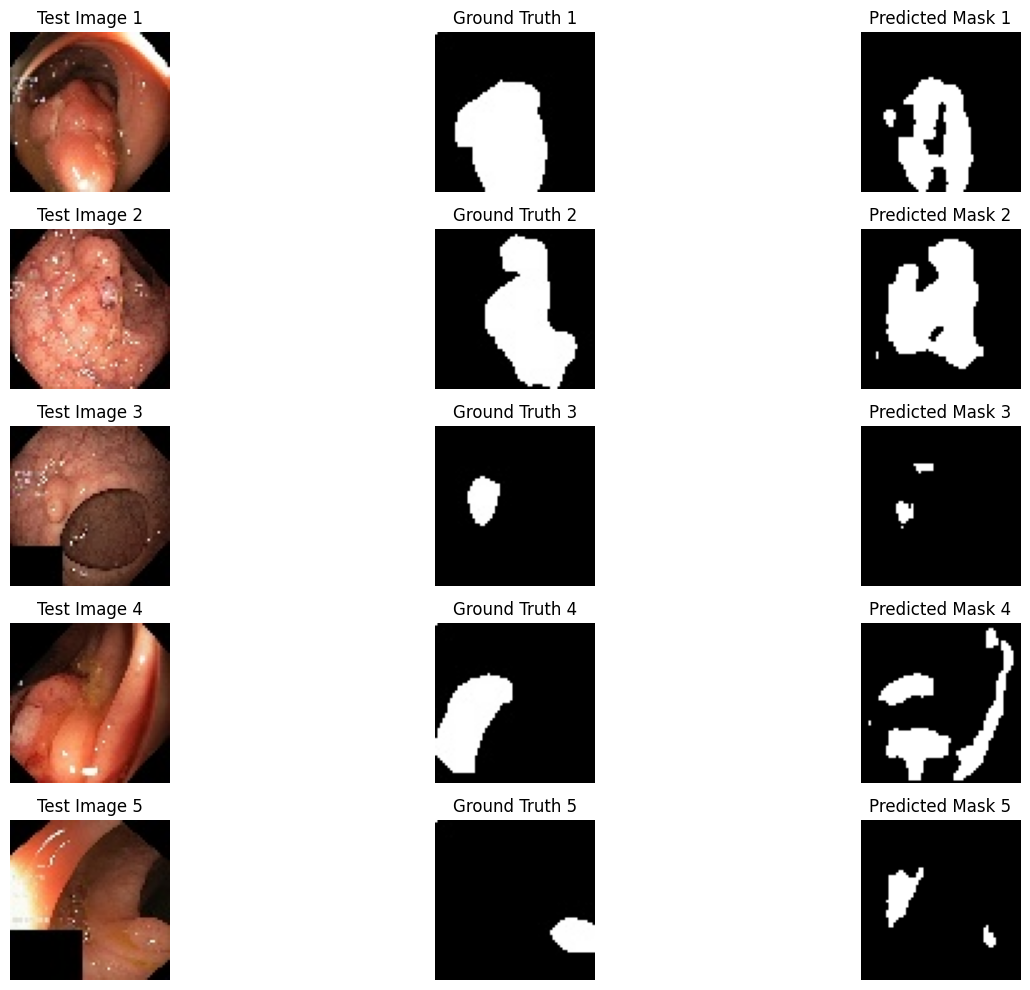

In [ ]:
import matplotlib.pyplot as plt

def plot_test_images(X_test, Y_test, y_pred, num_images=5):
    """
    Plots a few test images, their ground truth, and the predicted masks.

    Parameters:
    X_test: Input test images
    Y_test: Ground truth test masks
    y_pred: Predicted masks from the model
    num_images: Number of images to display (default is 5)
    """
    # Randomly select `num_images` indices to display
    indices = np.random.choice(range(len(X_test)), num_images, replace=False)

    plt.figure(figsize=(15, 10))

    for i, idx in enumerate(indices):
        # Get the image, ground truth mask, and predicted mask
        image = X_test[idx]
        true_mask = Y_test[idx]
        pred_mask = y_pred[idx]

                # Convert the image from BGR to RGB for proper display (if needed)
        image_rgb = image  # if images are already RGB, no conversion needed
        if image.shape[-1] == 3:  # Check if the image is in BGR format
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Plot the image, ground truth mask, and predicted mask
        plt.subplot(num_images, 3, 3 * i + 1)
        plt.imshow(image_rgb)
        plt.title(f"Test Image {i+1}")
        plt.axis('off')

        plt.subplot(num_images, 3, 3 * i + 2)
        plt.imshow(true_mask.squeeze(), cmap='gray')
        plt.title(f"Ground Truth {i+1}")
        plt.axis('off')

        plt.subplot(num_images, 3, 3 * i + 3)
        plt.imshow(pred_mask.squeeze(), cmap='gray')
        plt.title(f"Predicted Mask {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Predict on Test Set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)  # Binarize predictions

# Plot some of the test images, ground truth masks, and predicted masks
plot_test_images(X_test, Y_test, y_pred_thresholded)


In [ ]:
import numpy as np

def average_confidence_per_image(y_pred, threshold=0.5):
    """
    Computes the average confidence (probability) for each image in the predictions.
    You can apply a threshold to consider only pixels with higher confidence as foreground.

    Parameters:
    y_pred: Predicted masks from the model (probabilities)
    threshold: The probability threshold to classify pixels as foreground (default 0.5)

    Returns:
    avg_confidences: A list of average confidence scores for each image
    """
    avg_confidences = []

    for pred in y_pred:
        # Flatten the predictions for easier calculation
        pred_flattened = pred.flatten()

        # You can threshold the prediction to focus on foreground pixels
        foreground_pixels = pred_flattened[pred_flattened > threshold]  # Get foreground pixels above threshold

        if len(foreground_pixels) > 0:
            avg_confidence = np.mean(foreground_pixels)  # Calculate the average confidence for the foreground pixels
        else:
            avg_confidence = 0  # No foreground pixels with confidence above threshold

        avg_confidences.append(avg_confidence)

    return avg_confidences

# Assuming y_pred contains the raw output probabilities from the model
avg_confidences = average_confidence_per_image(y_pred, threshold=0.5)

# Print the average confidence for the first few images
print("Average Confidence for Test Images:")
for i, avg_conf in enumerate(avg_confidences[:5]):  # Display for the first 5 test images
    print(f"Image {i+1}: Average Confidence = {avg_conf:.4f}")


Average Confidence for Test Images:
Image 1: Average Confidence = 0.9666
Image 2: Average Confidence = 0.9460
Image 3: Average Confidence = 0.9337
Image 4: Average Confidence = 0.9484
Image 5: Average Confidence = 0.9368


In [ ]:
mean_avg_confidences= np.mean(avg_confidences)
print(f"Mean Average Confidence: {mean_avg_confidences}")
Std_avg_confidences= np.std(avg_confidences)
print(f"Standard Deviation of Average Confidence: {Std_avg_confidences}")

Mean Average Confidence: 0.9465944170951843
Standard Deviation of Average Confidence: 0.03988802060484886


In [ ]:
# prompt:  Find the indices of the bottom 20% images with the lowest average confidence

import numpy as np

def find_bottom_percentile_indices(avg_confidences, percentile=20):
    """
    Finds the indices of images with the lowest average confidence scores.

    Args:
        avg_confidences: A list or numpy array of average confidence scores.
        percentile: The desired percentile (e.g., 20 for the bottom 20%).

    Returns:
        A list of indices corresponding to the bottom percentile images.
    """
    # Calculate the threshold for the given percentile
    threshold = np.percentile(avg_confidences, percentile)

    # Find the indices of images with confidence below the threshold
    bottom_indices = np.where(avg_confidences <= threshold)[0]

    return bottom_indices

# Example usage:
bottom_20_indices = find_bottom_percentile_indices(avg_confidences, percentile=20)
print(f"Indices of images in the bottom 20% of average confidence: {bottom_20_indices}")



Indices of images in the bottom 20% of average confidence: [  6  24  27  29  30  35  37  38  42  43  46  51  54  57  60  61  62  67
  70  71  79  80  91 104 112 121 122 136 144 149]


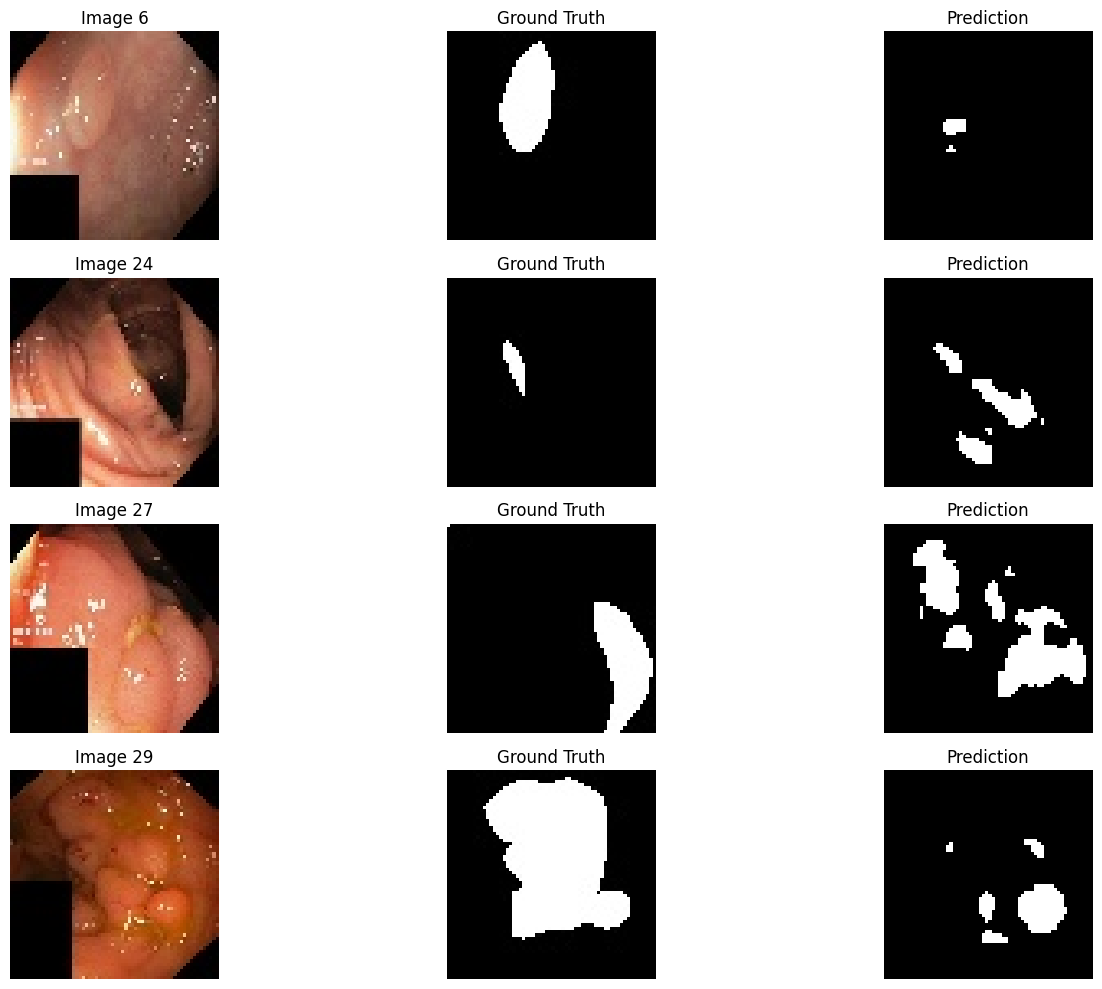

In [ ]:
# prompt: plot 4 of the images FROM bottom_20_indices FOR THE FIRST 4 indicies and the ground truth ND MODEL  PREDICTION

import matplotlib.pyplot as plt

def plot_bottom_images(X_test, Y_test, y_pred, bottom_indices, num_images=4):
    """Plots images, ground truth, and predictions for the specified indices."""
    plt.figure(figsize=(15, 10))
    for i in range(min(num_images, len(bottom_indices))):
        idx = bottom_indices[i]
        image = X_test[idx]
        true_mask = Y_test[idx]
        pred_mask = y_pred[idx]

        # Convert image from BGR to RGB if necessary
        image_rgb = image
        if image.shape[-1] == 3:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(num_images, 3, 3 * i + 1)
        plt.imshow(image_rgb)
        plt.title(f"Image {idx}")
        plt.axis('off')

        plt.subplot(num_images, 3, 3 * i + 2)
        plt.imshow(true_mask.squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        plt.subplot(num_images, 3, 3 * i + 3)
        plt.imshow(pred_mask.squeeze(), cmap='gray')
        plt.title("Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Assuming you have X_test, Y_test, y_pred, and bottom_20_indices defined
plot_bottom_images(X_test, Y_test, y_pred_thresholded, bottom_20_indices)


In [ ]:
from sklearn.metrics import accuracy_score

# Convert ground truth to binary (same threshold used for prediction)
Y_test_binary = (Y_test > 0.5).astype(np.float32)  # Apply threshold 0.5 to Y_test

# Calculate metrics only for the images in bottom_20_indices
iou_scores_bottom = [iou_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]
dice_scores_bottom = [dice_coef(np.float32(Y_test_binary[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]

mean_iou_bottom = np.mean(iou_scores_bottom)
mean_dice_bottom = np.mean(dice_scores_bottom)

# Accuracy calculation for bottom images
y_pred_bottom = model.predict(X_test[bottom_20_indices])
# Threshold y_pred_bottom to get binary predictions for accuracy calculation
y_pred_bottom_binary = (y_pred_bottom > 0.5).astype(np.float32)  # Convert to 0 and 1

# Accuracy based on binary comparison
accuracy_bottom = accuracy_score(Y_test_binary[bottom_20_indices].flatten(), y_pred_bottom_binary.flatten())

# Print the results
print(f"Test Accuracy (Bottom 20%): {accuracy_bottom}")
print(f"Test Dice Coefficient (Bottom 20%): {mean_dice_bottom}")
print(f"Test IoU (Bottom 20%): {mean_iou_bottom}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
Test Accuracy (Bottom 20%): 0.8867024739583333
Test Dice Coefficient (Bottom 20%): 0.3279159665107727
Test IoU (Bottom 20%): 0.21734467148780823


In [ ]:
# prompt: NOW i WANNA CALCULATE THE mean and std of the  avg confidance just for the test images in bottom 2o% indices

# Assuming avg_confidences and bottom_20_indices are already defined as in the previous code

# Extract average confidences for the bottom 20% of test images
bottom_avg_confidences = [avg_confidences[i] for i in bottom_20_indices]

# Calculate the mean and standard deviation of average confidences for the bottom 20%
mean_bottom_confidence = np.mean(bottom_avg_confidences)
std_bottom_confidence = np.std(bottom_avg_confidences)

print(f"Mean Average Confidence (Bottom 20%): {mean_bottom_confidence}")
print(f"Standard Deviation of Average Confidence (Bottom 20%): {std_bottom_confidence}")


Mean Average Confidence (Bottom 20%): 0.8880873322486877
Standard Deviation of Average Confidence (Bottom 20%): 0.05144205316901207




---
DATA AUGMENTATION


In [ ]:
X_train.shape

(700, 64, 64, 3)

In [ ]:
Y_train.shape

(700, 64, 64, 1)

In [ ]:
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define augmentation pipeline (no normalization for original-like data)
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], additional_targets={'mask': 'mask'})  # Disabled shape check

# Lists to store augmented data
X_aug = []
Y_aug = []

for x, y in zip(X_train, Y_train):
    # Transpose image from (C, H, W) to (H, W, C)
    #x = np.transpose(x, (1, 0, 2))  # From (64, 3, 64) to (64, 64, 3)

    # Check if the mask is already (H, W, C) format
    if y.shape[-1] == 3:  # Mask has 3 channels, likely redundant
        y = y[:, :, 0:1]  # Keep only the first channel (grayscale mask)

    # Ensure mask has 1 channel, as typically expected in segmentation tasks
    if y.shape[-1] == 1:  # Grayscale mask, should have 1 channel
        y = np.repeat(y, 3, axis=-1)  # Repeat across 3 channels to match image (if needed)

    # Print original shapes for debugging
    print(f"Original image shape: {x.shape}, Original mask shape: {y.shape}")

    # Augment the image and mask
    augmented = augment(image=x, mask=y)
    x_aug = augmented["image"]
    y_aug = augmented["mask"]

    # Print augmented shapes for debugging
    print(f"Augmented image shape: {x_aug.shape}, Augmented mask shape: {y_aug.shape}")

    # Transpose back to CHW (from HWC to CHW)
    #y_aug = np.transpose(y_aug, (1, 0, 2))  # Back to (3, 64, 64)
    if y_aug.ndim == 2:  # If it's (H, W)
        y_aug = y_aug[:, :, np.newaxis]  # Add channel dimension: (H, W, 1)
    elif y_aug.ndim == 3 and y_aug.shape[0] < y_aug.shape[-1]:  # If it's (1, H, W)
        y_aug = np.transpose(y_aug, (1, 2, 0))  # Change to (H, W, 1)
    # If it's (H, W, 3) convert it to (H, W, 1)
    elif y_aug.ndim == 3 and y_aug.shape[-1] == 3:
        # Convert y_aug back to single channel (grayscale)
        y_aug = y_aug[:, :, 0:1]

    # Append to lists
    X_aug.append(x_aug)
    Y_aug.append(y_aug)

# Convert to NumPy arrays
X_aug = np.array(X_aug)
Y_aug = np.array(Y_aug)

# Combine with original data
X_train_combined = np.concatenate((X_train, X_aug))
Y_train_combined = np.concatenate((Y_train, Y_aug))

# Print final shapes
print("Final X_train_combined shape:", X_train_combined.shape)
print("Final Y_train_combined shape:", Y_train_combined.shape)


In [ ]:
# prompt: fit this data in to the model

# Assuming X_train, Y_train, X_val, Y_val, X_test, Y_test, and model are defined as in the preceding code.
# Assuming X_train_combined and Y_train_combined are defined from the data augmentation section.


# Compile the model (if not already compiled)
model.compile(optimizer=Adam(learning_rate=1e-4), loss=combined_loss, metrics=['accuracy', dice_coef, iou_coef])

# Train the model using the combined augmented dataset
history_augmented = model.fit(X_train_combined, Y_train_combined, validation_data=(X_val, Y_val), epochs=10, batch_size=4)


# Evaluate the model on the test set
y_pred = model.predict(X_test)
y_pred_thresholded = (y_pred > 0.5).astype(np.float32)

# Calculate metrics
iou_scores = [iou_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]
dice_scores = [dice_coef(Y_test[i], y_pred_thresholded[i]).numpy() for i in range(len(Y_test))]

mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_scores)

print(f"Test Accuracy: {model.evaluate(X_test, Y_test)[1]}")
print(f"Test Dice Coefficient: {mean_dice}")
print(f"Test IoU: {mean_iou}")


Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9074 - dice_coef: 0.9117 - iou_coef: 0.8418 - loss: 0.1407 - val_accuracy: 0.8345 - val_dice_coef: 0.6068 - val_iou_coef: 0.4444 - val_loss: 0.5155
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9081 - dice_coef: 0.9130 - iou_coef: 0.8434 - loss: 0.1392 - val_accuracy: 0.8413 - val_dice_coef: 0.6211 - val_iou_coef: 0.4602 - val_loss: 0.5001
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9111 - dice_coef: 0.9217 - iou_coef: 0.8579 - loss: 0.1262 - val_accuracy: 0.8393 - val_dice_coef: 0.6036 - val_iou_coef: 0.4407 - val_loss: 0.5187
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9118 - dice_coef: 0.9251 - iou_coef: 0.8635 - loss: 0.1211 - val_accuracy: 0.8378 - val_dice_coef: 0.6012 - val_iou_coef: 0.4400 - val_loss: 0.5188
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9118 - dice_coef: 0.9229 - iou_coef: 0.8596 - loss: 0.1246 - val_accurac

In [ ]:
# prompt: calculate mean and std of average confidance of each test image

# Assuming y_pred contains the raw output probabilities from the model
avg_confidences = average_confidence_per_image(y_pred, threshold=0.5)

mean_avg_confidences = np.mean(avg_confidences)
print(f"Mean Average Confidence: {mean_avg_confidences}")
std_avg_confidences = np.std(avg_confidences)
print(f"Standard Deviation of Average Confidence: {std_avg_confidences}")


Mean Average Confidence: 0.9575288891792297
Standard Deviation of Average Confidence: 0.030853036791086197


In [ ]:
# prompt: calculate accuracy and IOU aand DICE for test images with index: bottom_20_indices

# Calculate metrics only for the images in bottom_20_indices
iou_scores_bottom = [iou_coef(np.float32(Y_test[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]
dice_scores_bottom = [dice_coef(np.float32(Y_test[i]), np.float32(y_pred_thresholded[i])).numpy() for i in bottom_20_indices]

mean_iou_bottom = np.mean(iou_scores_bottom)
mean_dice_bottom = np.mean(dice_scores_bottom)

# Accuracy calculation for bottom images
y_pred_bottom = model.predict(X_test[bottom_20_indices])
# Threshold y_pred_bottom to get binary predictions for accuracy calculation
y_pred_bottom_binary = (y_pred_bottom > 0.5).astype(np.float32)  # Convert to 0 and 1

# Accuracy based on binary comparison
# Ensure Y_test is also binary for accurate accuracy calculation
Y_test_binary = (Y_test > 0.5).astype(np.float32)
accuracy_bottom = accuracy_score(Y_test_binary[bottom_20_indices].flatten(), y_pred_bottom_binary.flatten())


# Print the results
print(f"Test Accuracy (Bottom 20%): {accuracy_bottom}")
print(f"Test Dice Coefficient (Bottom 20%): {mean_dice_bottom}")
print(f"Test IoU (Bottom 20%): {mean_iou_bottom}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Test Accuracy (Bottom 20%): 0.8931477864583334
Test Dice Coefficient (Bottom 20%): 0.4049270749092102
Test IoU (Bottom 20%): 0.27788400650024414


In [ ]:
# prompt: calculate mean and std of the average confidance of test images with bottom_20_indices

# Assuming avg_confidences and bottom_20_indices are already defined as in the previous code

# Extract average confidences for the bottom 20% of test images
bottom_avg_confidences = [avg_confidences[i] for i in bottom_20_indices]

# Calculate the mean and standard deviation of average confidences for the bottom 20%
mean_bottom_confidence = np.mean(bottom_avg_confidences)
std_bottom_confidence = np.std(bottom_avg_confidences)

print(f"Mean Average Confidence (Bottom 20%): {mean_bottom_confidence}")
print(f"Standard Deviation of Average Confidence (Bottom 20%): {std_bottom_confidence}")


Mean Average Confidence (Bottom 20%): 0.9149420261383057
Standard Deviation of Average Confidence (Bottom 20%): 0.039752859622240067


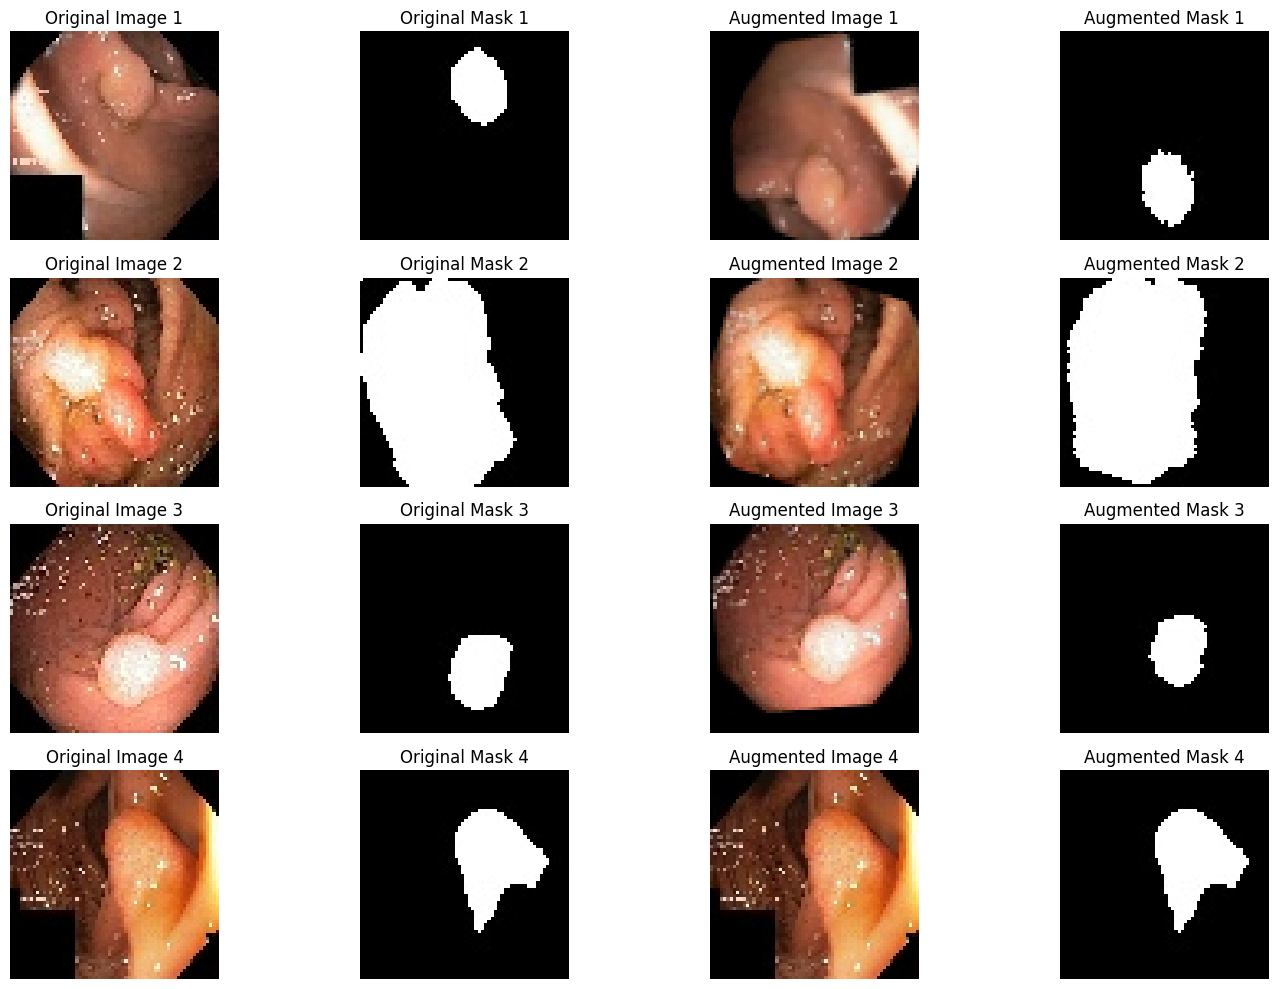

In [ ]:
# prompt: plot 4 example of the original image and it's augmentation and their coresponding masks

import matplotlib.pyplot as plt

def plot_augmented_images(X_train, Y_train, X_aug, Y_aug, num_images=4):
    """Plots original and augmented images with their masks."""
    plt.figure(figsize=(15, 10))
    for i in range(num_images):
        idx = np.random.randint(0, len(X_train))
        image = X_train[idx]
        true_mask = Y_train[idx]
        image_aug = X_aug[idx]
        mask_aug = Y_aug[idx]

        # Convert image from BGR to RGB if necessary
        image_rgb = image
        if image.shape[-1] == 3:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_aug_rgb = image_aug
        if image_aug.shape[-1] == 3:
            image_aug_rgb = cv2.cvtColor(image_aug, cv2.COLOR_BGR2RGB)


        plt.subplot(num_images, 4, 4 * i + 1)
        plt.imshow(image_rgb)
        plt.title(f"Original Image {i + 1}")
        plt.axis('off')

        plt.subplot(num_images, 4, 4 * i + 2)
        plt.imshow(true_mask.squeeze(), cmap='gray')
        plt.title(f"Original Mask {i + 1}")
        plt.axis('off')

        plt.subplot(num_images, 4, 4 * i + 3)
        plt.imshow(image_aug_rgb)
        plt.title(f"Augmented Image {i + 1}")
        plt.axis('off')

        plt.subplot(num_images, 4, 4 * i + 4)
        plt.imshow(mask_aug.squeeze(), cmap='gray')
        plt.title(f"Augmented Mask {i + 1}")
        plt.axis('off')


    plt.tight_layout()
    plt.show()

plot_augmented_images(X_train, Y_train, X_aug, Y_aug)


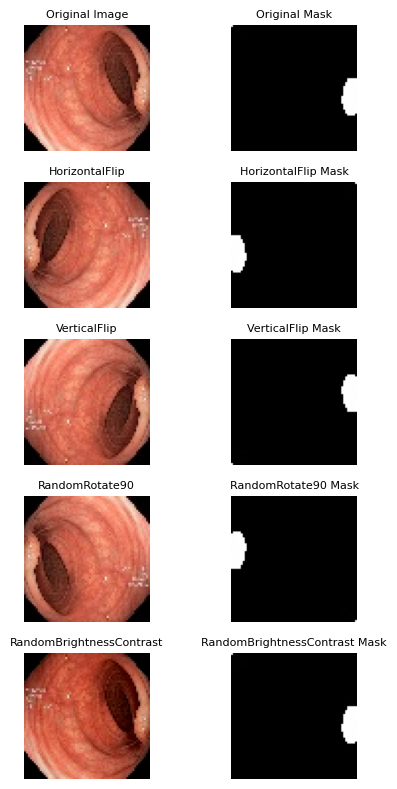

In [ ]:
# prompt: plot 4 example(different type of augmentation) of the original image and it's augmentation and their coresponding masks also name the type of augmentation

import matplotlib.pyplot as plt
import numpy as np
import cv2
import albumentations as A

def plot_augmentations(image, mask, augmentations, num_examples=4):
    """Plots the original image and mask alongside augmented versions."""

    plt.figure(figsize=(5, 2 * num_examples))

    # Plot the original image and mask
    plt.subplot(num_examples + 1, 2,1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
    plt.title("Original Image", fontsize=8)
    plt.axis("off")

    plt.subplot(num_examples + 1,2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Original Mask",fontsize=8)
    plt.axis("off")


    for i, augment in enumerate(augmentations):
        augmented = augment(image=image, mask=mask)
        augmented_image = augmented["image"]
        augmented_mask = augmented["mask"]

        plt.subplot( num_examples + 1,2, 2 * (i + 2) - 1)
        plt.imshow(cv2.cvtColor(augmented_image, cv2.COLOR_BGR2RGB))
        plt.title(f"{augment.__class__.__name__}",fontsize=8)
        plt.axis("off")

        plt.subplot(num_examples + 1,2, 2 * (i + 2))
        plt.imshow(augmented_mask, cmap="gray")
        plt.title(f"{augment.__class__.__name__} Mask",fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example usage (replace with your actual image and mask data)
# Assuming X_train and Y_train contain your image and mask data

# Choose a random image and its corresponding mask from your training data
random_index = np.random.randint(0, len(X_train))
image = X_train[random_index]
mask = Y_train[random_index]

# Example augmentation transforms
augmentations = [
    A.HorizontalFlip(p=1),
    A.VerticalFlip(p=1),
    A.RandomRotate90(p=1),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1),
]

# Plot the augmentations
plot_augmentations(image, mask.squeeze(), augmentations)  # Remove extra dimension from mask
